<a href="https://colab.research.google.com/github/Narges-Sefid/MachineLearning/blob/main/WindForecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import xarray as xr

In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns

In [ ]:
import xarray as xr
import os

#ERA5 Data

##2024

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2024-wind100-2.nc'
wnd1002024 = xr.open_dataset(file_path)
print(wnd1002024)

<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 141kB ...
Data variables:
    u100        (valid_time, latitude, longitude) float32 8MB ...
    v100        (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-20T03:54 GRIB to CDM+CF via cfgrib-0.9.1...


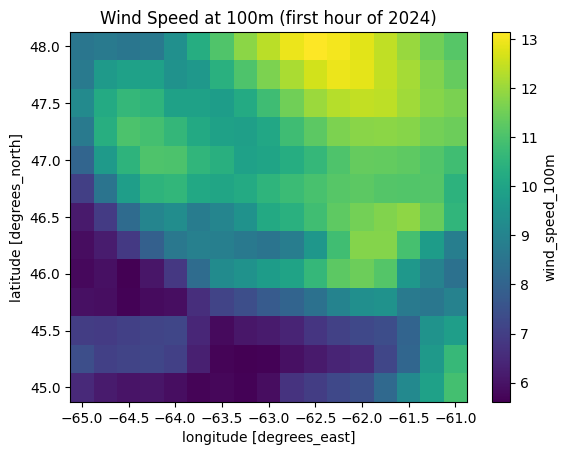

In [ ]:


# Compute wind speed
wnd1002024['wind_speed_100m'] = np.sqrt(wnd1002024['u100']**2 + wnd1002024['v100']**2)

# Plot wind speed at first valid_time step
wnd1002024['wind_speed_100m'].isel(valid_time=0).plot(cmap='viridis')
plt.title('Wind Speed at 100m (first hour of 2024)')
plt.show()


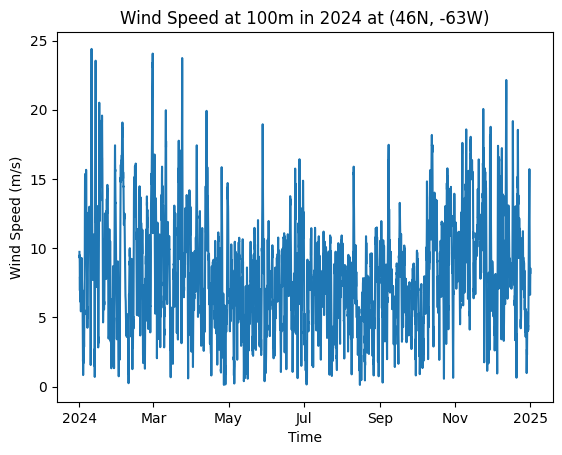

In [ ]:
point_data = wnd1002024['wind_speed_100m'].sel(latitude=46.0, longitude=-63.0, method='nearest')

# Plot time series
point_data.plot()
plt.title('Wind Speed at 100m in 2024 at (46N, -63W)')
plt.ylabel('Wind Speed (m/s)')
plt.xlabel('Time')
plt.show()


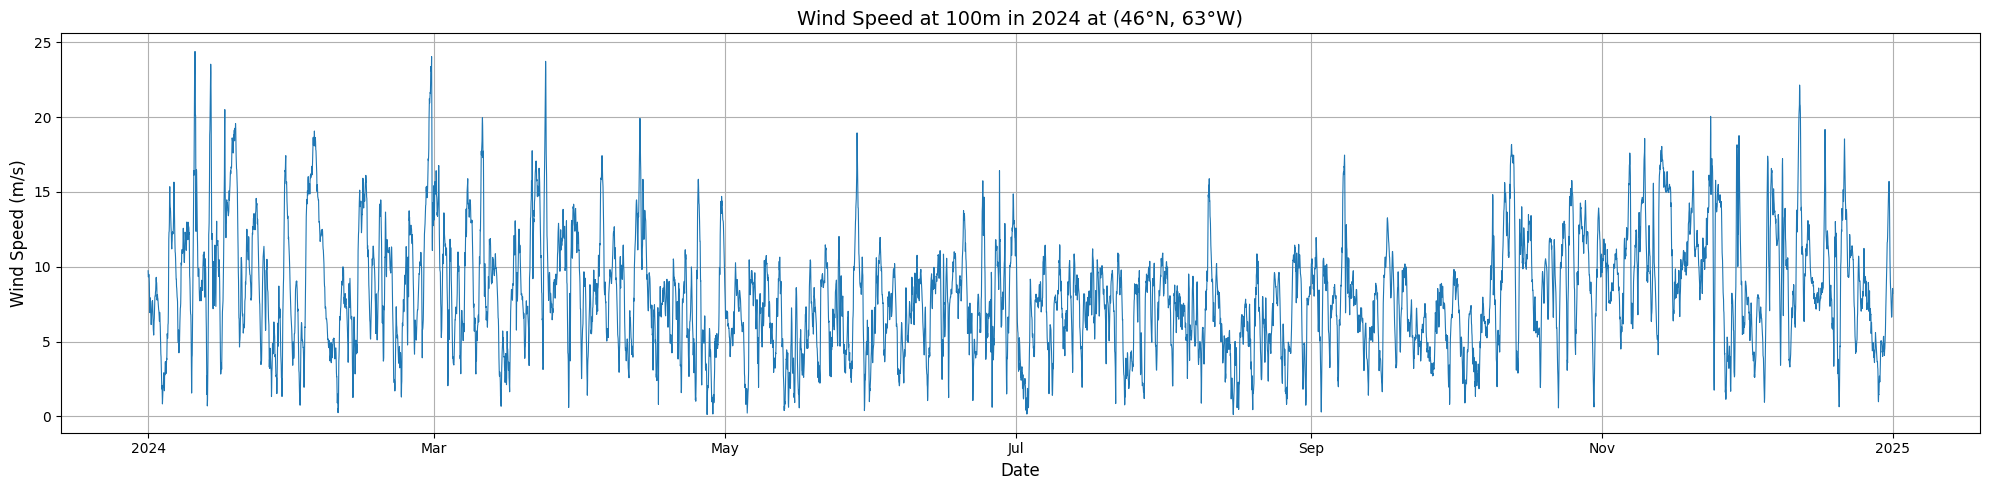

In [ ]:

# Extract wind speed at a specific location (nearest grid cell)
point_data = wnd1002024['wind_speed_100m'].sel(latitude=46.0, longitude=-63.0)#, method='nearest')

# Plot with larger figure and better formatting
plt.figure(figsize=(20, 5))  # Wider figure (width x height in inches)
point_data.plot(linewidth=0.8)

plt.title('Wind Speed at 100m in 2024 at (46°N, 63°W)', fontsize=14)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


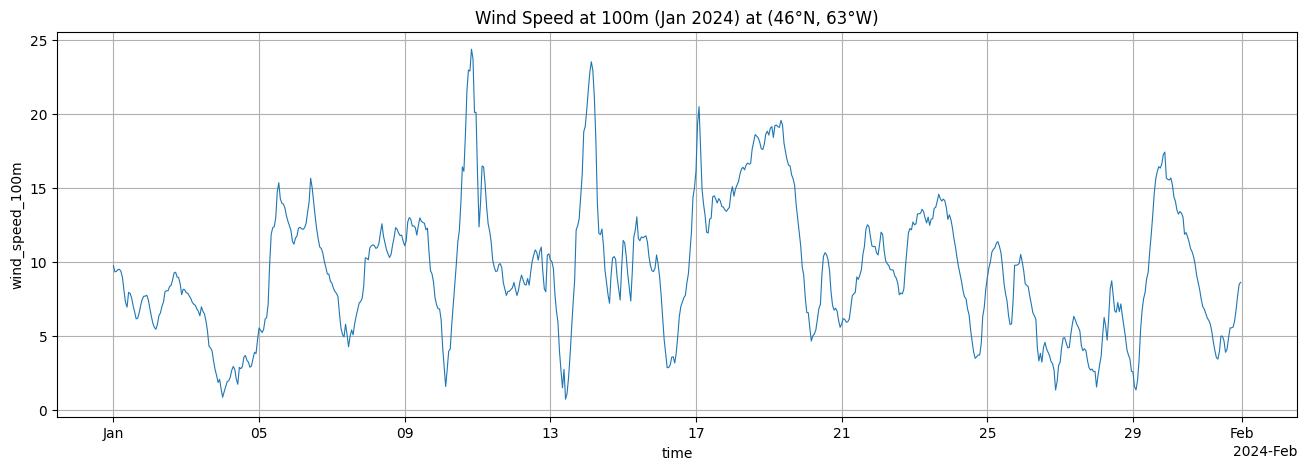

In [ ]:
# Zoom in to, say, January
subset = point_data.sel(valid_time=slice('2024-01-01', '2024-01-31'))

plt.figure(figsize=(16, 5))
subset.plot(linewidth=0.8)
plt.title('Wind Speed at 100m (Jan 2024) at (46°N, 63°W)')
plt.grid(True)
plt.show()

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2024-wind10-2.nc'
wnd102024 = xr.open_dataset(file_path)
print(wnd102024)

<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 141kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 8MB ...
    v10         (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-21T22:37 GRIB to CDM+CF via cfgrib-0.9.1...


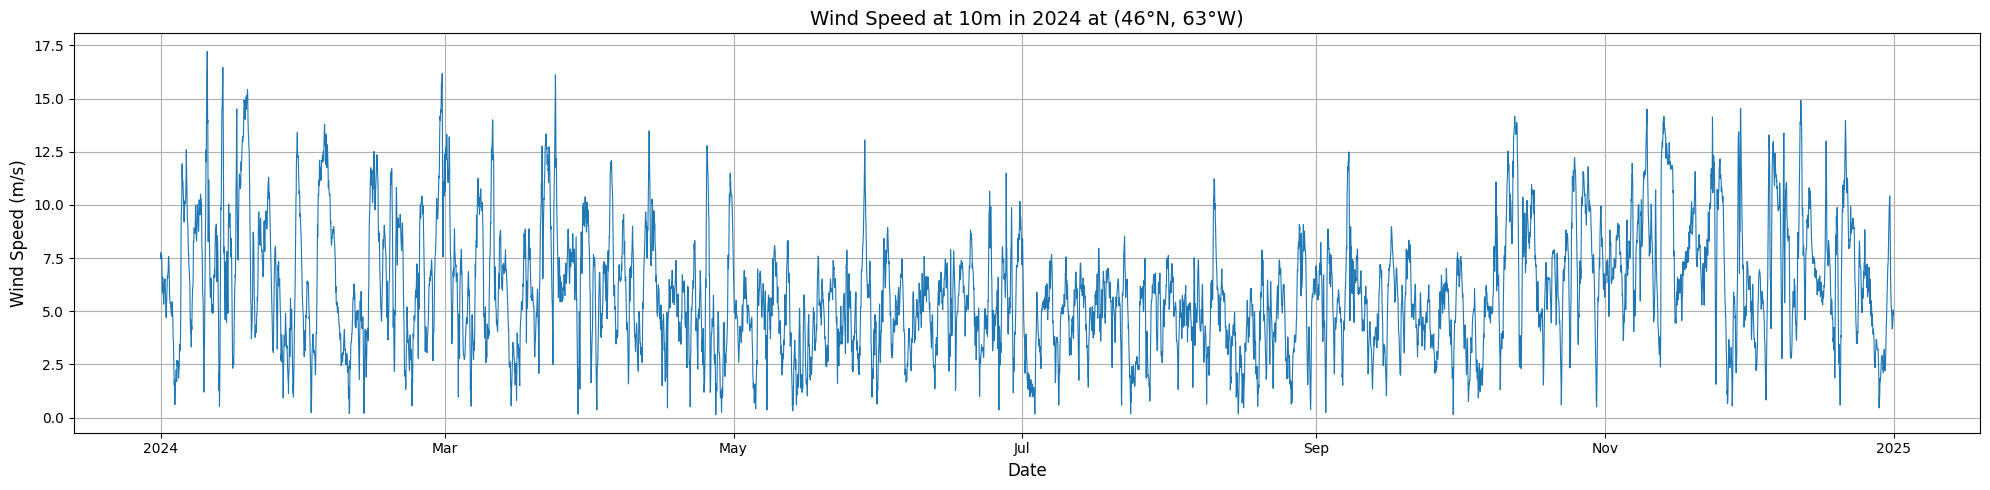

In [ ]:
# Compute wind speed
wnd102024['wind_speed_10m'] = np.sqrt(wnd102024['u10']**2 + wnd102024['v10']**2)
# Extract wind speed at a specific location (nearest grid cell)
point_data = wnd102024['wind_speed_10m'].sel(latitude=46.0, longitude=-63.0)#, method='nearest')

# Plot with larger figure and better formatting
plt.figure(figsize=(20, 5))  # Wider figure (width x height in inches)
point_data.plot(linewidth=0.8)

plt.title('Wind Speed at 10m in 2024 at (46°N, 63°W)', fontsize=14)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Merge datasets
combined = xr.merge([wnd102024, wnd1002024])

# Confirm everything is together
print(combined)

<xarray.Dataset> Size: 47MB
Dimensions:          (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB 5.803 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB -4.287 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 7.215 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 6.755 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -5.264 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 8.564 ... ...
Attributes:
    GRIB_centre:             e

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2024-temp.nc'
temp2024 = xr.open_dataset(file_path)
print(temp2024)

<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 141kB ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 8MB ...
    t2m         (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-22T00:19 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
# Merge temperature and dewpoint into the combined dataset
combined = xr.merge([combined, temp2024])

In [ ]:
combined['temp_C'] = combined['t2m'] - 273.15
combined['dewpoint_C'] = combined['d2m'] - 273.15

In [ ]:
print(combined)

<xarray.Dataset> Size: 78MB
Dimensions:          (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB 5.803 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB -4.287 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 7.215 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 6.755 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -5.264 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 8.564 ... ...
    d2m              (valid_time, latitude

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2024-prec.nc'
prec2024 = xr.open_dataset(file_path)
print(prec2024)

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 141kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-22T00:50 GRIB to CDM+CF via cfgrib-0.9.1...


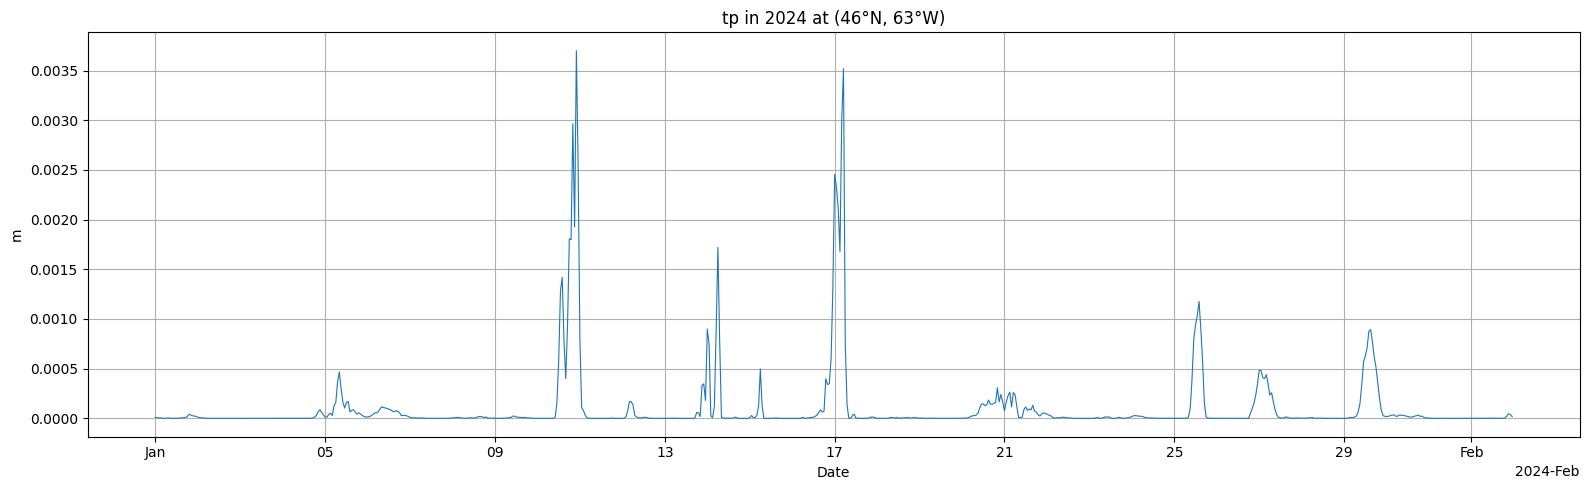

In [ ]:
# Extract a variable (replace 'your_variable' with the actual name, e.g., 'tp', 'sp', etc.)
var = prec2024['tp']

# Pick the nearest grid point to 46N, -63W
point_data = var.sel(latitude=46.0, longitude=-63.0, method='nearest')

# Limit to 2024 (optional if already filtered)
point_data = point_data.sel(valid_time=slice('2024-01-01', '2024-02-01'))

# Plot
plt.figure(figsize=(16, 5))
point_data.plot(linewidth=0.8)
plt.title(f"{var.name} in 2024 at (46°N, 63°W)")
plt.xlabel("Date")
plt.ylabel(var.attrs.get("units", var.name))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(prec2024.valid_time.values[:10])

['2024-01-01T00:00:00.000000000' '2024-01-01T01:00:00.000000000'
 '2024-01-01T02:00:00.000000000' '2024-01-01T03:00:00.000000000'
 '2024-01-01T04:00:00.000000000' '2024-01-01T05:00:00.000000000'
 '2024-01-01T06:00:00.000000000' '2024-01-01T07:00:00.000000000'
 '2024-01-01T08:00:00.000000000' '2024-01-01T09:00:00.000000000']


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2024-pres.nc'
pres2024 = xr.open_dataset(file_path)
print(pres2024)

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 141kB ...
Data variables:
    sp          (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-22T00:50 GRIB to CDM+CF via cfgrib-0.9.1...


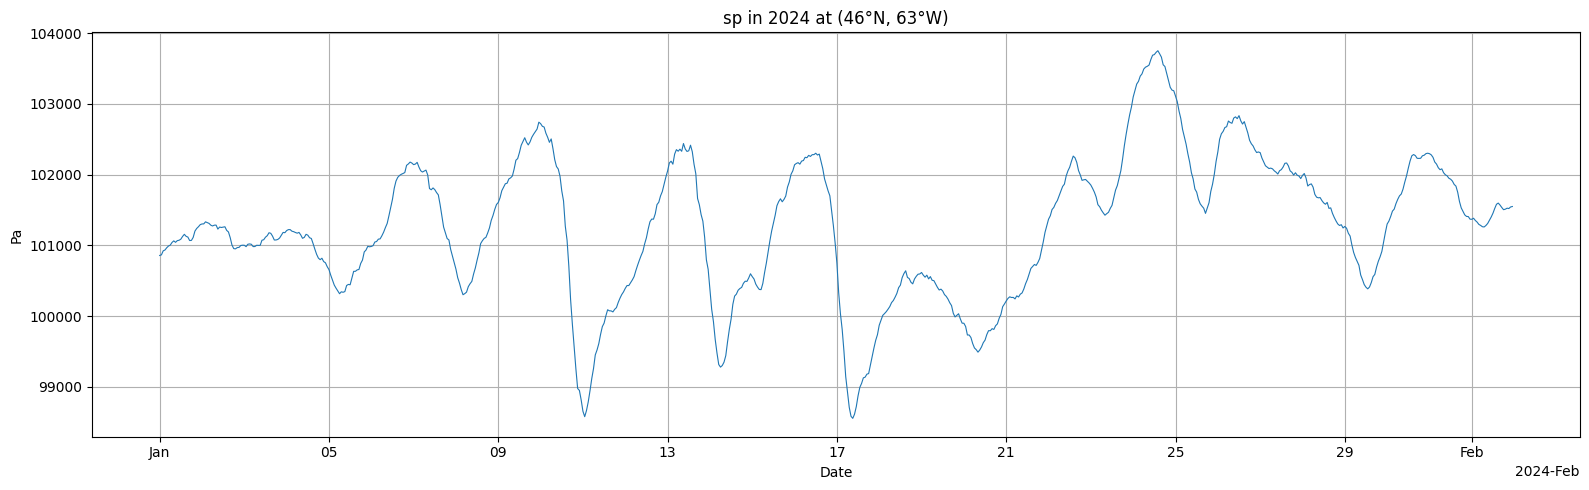

In [ ]:
# Extract a variable (replace 'your_variable' with the actual name, e.g., 'tp', 'sp', etc.)
var = pres2024['sp']

# Pick the nearest grid point to 46N, -63W
point_data = var.sel(latitude=46.0, longitude=-63.0, method='nearest')

# Limit to 2024 (optional if already filtered)
point_data = point_data.sel(valid_time=slice('2024-01-01', '2024-02-01'))

# Plot
plt.figure(figsize=(16, 5))
point_data.plot(linewidth=0.8)
plt.title(f"{var.name} in 2024 at (46°N, 63°W)")
plt.xlabel("Date")
plt.ylabel(var.attrs.get("units", var.name))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(pres2024.valid_time.values[:10])

['2024-01-01T00:00:00.000000000' '2024-01-01T01:00:00.000000000'
 '2024-01-01T02:00:00.000000000' '2024-01-01T03:00:00.000000000'
 '2024-01-01T04:00:00.000000000' '2024-01-01T05:00:00.000000000'
 '2024-01-01T06:00:00.000000000' '2024-01-01T07:00:00.000000000'
 '2024-01-01T08:00:00.000000000' '2024-01-01T09:00:00.000000000']


In [ ]:
combined = xr.merge([combined, prec2024, pres2024])

In [ ]:
print(combined)

<xarray.Dataset> Size: 93MB
Dimensions:          (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB 5.803 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB -4.287 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 7.215 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 6.755 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -5.264 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 8.564 ... ...
    d2m              (valid_time, latitude

In [ ]:
combined2024 = combined

In [ ]:
print(combined2024)

<xarray.Dataset> Size: 93MB
Dimensions:          (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB 5.803 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB -4.287 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 7.215 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 6.755 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -5.264 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 8.564 ... ...
    d2m              (valid_time, latitude

In [ ]:
combined2024

<xarray.Dataset> Size: 93MB
Dimensions:          (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB 5.803 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB -4.287 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 7.215 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 6.755 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -5.264 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 8.564 ... ...
    d2m              (valid_time, latitude, longitude) float32 8MB 265.2 ... ...
    t2m              (valid_time, latitude, longitude) float32 8MB 270.8 ... ...
    temp_C           (valid_time, latitude, longitude) float32 8MB -2.32 ... ...
    dewpoint_C       (valid_time, latitude, longitude) float32 8MB -7.959 ......
    tp               (valid_time, latitude, longitude) float32 8MB ...
    sp               (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-21T22:37 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
min_val = combined2024['wind_speed_100m'].min()
max_val = combined2024['wind_speed_100m'].max()

print("Min wind speed at 100m:", min_val)
print("Max wind speed at 100m:", max_val)

Min wind speed at 100m: <xarray.DataArray 'wind_speed_100m' ()> Size: 8B
array(0.0054751)
Coordinates:
    number   int64 8B 0
Max wind speed at 100m: <xarray.DataArray 'wind_speed_100m' ()> Size: 8B
array(30.60704041)
Coordinates:
    number   int64 8B 0


##2023

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2023-wind100-2.nc'
wnd1002023 = xr.open_dataset(file_path)
print(wnd1002023)

<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 8760, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 140kB ...
Data variables:
    u100        (valid_time, latitude, longitude) float32 8MB ...
    v100        (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-22T20:24 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
# Compute wind speed
wnd1002023['wind_speed_100m'] = np.sqrt(wnd1002023['u100']**2 + wnd1002023['v100']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2023-wind10-2.nc'
wnd102023 = xr.open_dataset(file_path)
print(wnd102023)

<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 8760, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 140kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 8MB ...
    v10         (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-22T22:17 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
# Compute wind speed
wnd102023['wind_speed_10m'] = np.sqrt(wnd102023['u10']**2 + wnd102023['v10']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2023-temp.nc'
temp2023 = xr.open_dataset(file_path)
print(temp2023)

<xarray.Dataset> Size: 16MB
Dimensions:     (valid_time: 8760, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 140kB ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 8MB ...
    t2m         (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-22T22:39 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
temp2023['temp_C'] = temp2023['t2m'] - 273.15
temp2023['dewpoint_C'] = temp2023['d2m'] - 273.15

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2023-prec.nc'
prec2023 = xr.open_dataset(file_path)
print(prec2023)

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 8760, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 140kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-22T23:09 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2023-pres.nc'
pres2023 = xr.open_dataset(file_path)
print(pres2023)

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 8760, latitude: 13, longitude: 17)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23...
  * latitude    (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 136B -65.0 -64.75 -64.5 ... -61.25 -61.0
    expver      (valid_time) <U4 140kB ...
Data variables:
    sp          (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-22T23:09 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
# Merge datasets
combined2023 = xr.merge([wnd102023, wnd1002023, temp2023, prec2023, pres2023])

# Confirm everything is together
print(combined2023)

<xarray.Dataset> Size: 93MB
Dimensions:          (valid_time: 8760, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 140kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB 1.375 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB -0.3969 .....
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 1.431 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 2.579 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -0.7452 .....
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 2.685 ... ...
    d2m              (valid_time, latitude

##2022

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2022-wind100-2.nc'
wnd1002022 = xr.open_dataset(file_path)

In [ ]:
# Compute wind speed
wnd1002022['wind_speed_100m'] = np.sqrt(wnd1002022['u100']**2 + wnd1002022['v100']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2022-wind10-2.nc'
wnd102022 = xr.open_dataset(file_path)

In [ ]:
# Compute wind speed
wnd102022['wind_speed_10m'] = np.sqrt(wnd102022['u10']**2 + wnd102022['v10']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2022-temp.nc'
temp2022 = xr.open_dataset(file_path)

In [ ]:
temp2022['temp_C'] = temp2022['t2m'] - 273.15
temp2022['dewpoint_C'] = temp2022['d2m'] - 273.15

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2022-prec.nc'
prec2022 = xr.open_dataset(file_path)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2022-pres.nc'
pres2022 = xr.open_dataset(file_path)

In [ ]:
# Merge datasets
combined2022 = xr.merge([wnd102022, wnd1002022, temp2022, prec2022, pres2022])

# Confirm everything is together
print(combined2022)

<xarray.Dataset> Size: 93MB
Dimensions:          (valid_time: 8760, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2022-01-01 ... 2022-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 140kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB 1.245 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB 1.421 ... ...
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 1.889 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 1.375 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB 2.126 ... ...
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 2.532 ... ...
    d2m              (valid_time, latitude

##2022-2023

In [ ]:
combined2223 = xr.combine_by_coords([combined2022, combined2023],combine_attrs="override")

In [ ]:
print(combined2223)

<xarray.Dataset> Size: 186MB
Dimensions:          (valid_time: 17520, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 140kB 2022-01-01 ... 2023-12...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 280kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 15MB 1.245 ......
    v10              (valid_time, latitude, longitude) float32 15MB 1.421 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 15MB 1.889 ......
    u100             (valid_time, latitude, longitude) float32 15MB 1.375 ......
    v100             (valid_time, latitude, longitude) float32 15MB 2.126 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 15MB 2.532 ......
    d2m              (valid_time, latitu

##2021

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2021-wind100-2.nc'
wnd1002021 = xr.open_dataset(file_path)

In [ ]:
# Compute wind speed
wnd1002021['wind_speed_100m'] = np.sqrt(wnd1002021['u100']**2 + wnd1002021['v100']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2021-wind10-2.nc'
wnd102021 = xr.open_dataset(file_path)

In [ ]:
# Compute wind speed
wnd102021['wind_speed_10m'] = np.sqrt(wnd102021['u10']**2 + wnd102021['v10']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2021-temp.nc'
temp2021 = xr.open_dataset(file_path)

In [ ]:
temp2021['temp_C'] = temp2021['t2m'] - 273.15
temp2021['dewpoint_C'] = temp2021['d2m'] - 273.15

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2021-prec.nc'
prec2021 = xr.open_dataset(file_path)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2021-pres.nc'
pres2021 = xr.open_dataset(file_path)

In [ ]:
# Merge datasets
combined2021 = xr.merge([wnd102021, wnd1002021, temp2021, prec2021, pres2021])

# Confirm everything is together
print(combined2021)

<xarray.Dataset> Size: 93MB
Dimensions:          (valid_time: 8760, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 140kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB 9.19 ... 0...
    v10              (valid_time, latitude, longitude) float32 8MB -1.479 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 9.308 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 12.09 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -2.44 ... ...
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 12.33 ... ...
    d2m              (valid_time, latitude

##2021-2023

In [ ]:
combined2123 = xr.combine_by_coords([combined2021, combined2223],combine_attrs="override")

In [ ]:
combined2123

<xarray.Dataset> Size: 279MB
Dimensions:          (valid_time: 26280, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 210kB 2021-01-01 ... 2023-12...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 420kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 23MB 9.19 ... ...
    v10              (valid_time, latitude, longitude) float32 23MB -1.479 .....
    wind_speed_10m   (valid_time, latitude, longitude) float32 23MB 9.308 ......
    u100             (valid_time, latitude, longitude) float32 23MB 12.09 ......
    v100             (valid_time, latitude, longitude) float32 23MB -2.44 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 23MB 12.33 ......
    d2m              (valid_time, latitude, longitude) float32 23MB 265.0 ......
    t2m              (valid_time, latitude, longitude) float32 23MB 270.3 ......
    temp_C           (valid_time, latitude, longitude) float32 23MB -2.824 .....
    dewpoint_C       (valid_time, latitude, longitude) float32 23MB -8.112 .....
    tp               (valid_time, latitude, longitude) float32 23MB 0.0 ... 1...
    sp               (valid_time, latitude, longitude) float32 23MB 1.005e+05...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-23T01:33 GRIB to CDM+CF via cfgrib-0.9.1...

##2020

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2020-wind100-2.nc'
wnd1002020 = xr.open_dataset(file_path)

In [ ]:
# Compute wind speed
wnd1002020['wind_speed_100m'] = np.sqrt(wnd1002020['u100']**2 + wnd1002020['v100']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2020-wind10-2.nc'
wnd102020 = xr.open_dataset(file_path)

In [ ]:
# Compute wind speed
wnd102020['wind_speed_10m'] = np.sqrt(wnd102020['u10']**2 + wnd102020['v10']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2020-temp.nc'
temp2020 = xr.open_dataset(file_path)

In [ ]:
temp2020['temp_C'] = temp2020['t2m'] - 273.15
temp2020['dewpoint_C'] = temp2020['d2m'] - 273.15

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2020-prec.nc'
prec2020 = xr.open_dataset(file_path)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2020-pres.nc'
pres2020 = xr.open_dataset(file_path)

In [ ]:
# Merge datasets
combined2020 = xr.merge([wnd102020, wnd1002020, temp2020, prec2020, pres2020])

# Confirm everything is together
print(combined2020)

<xarray.Dataset> Size: 93MB
Dimensions:          (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 8MB -10.61 ......
    v10              (valid_time, latitude, longitude) float32 8MB -0.01851 ....
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 10.61 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB -14.22 ......
    v100             (valid_time, latitude, longitude) float32 8MB 0.3263 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 14.22 ... ...
    d2m              (valid_time, latitude

##2020-2022

In [ ]:
combined202023 = xr.combine_by_coords([combined2020, combined2123],combine_attrs="override")

In [ ]:
combined202023

<xarray.Dataset> Size: 373MB
Dimensions:          (valid_time: 35064, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 281kB 2020-01-01 ... 2023-12...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 561kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 31MB -10.61 .....
    v10              (valid_time, latitude, longitude) float32 31MB -0.01851 ...
    wind_speed_10m   (valid_time, latitude, longitude) float32 31MB 10.61 ......
    u100             (valid_time, latitude, longitude) float32 31MB -14.22 .....
    v100             (valid_time, latitude, longitude) float32 31MB 0.3263 .....
    wind_speed_100m  (valid_time, latitude, longitude) float32 31MB 14.22 ......
    d2m              (valid_time, latitude, longitude) float32 31MB 269.8 ......
    t2m              (valid_time, latitude, longitude) float32 31MB 271.1 ......
    temp_C           (valid_time, latitude, longitude) float32 31MB -2.094 .....
    dewpoint_C       (valid_time, latitude, longitude) float32 31MB -3.394 .....
    tp               (valid_time, latitude, longitude) float32 31MB 0.002068 ...
    sp               (valid_time, latitude, longitude) float32 31MB 9.988e+04...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-23T02:48 GRIB to CDM+CF via cfgrib-0.9.1...

##2019

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2019-wind100-2.nc'
wnd1002019 = xr.open_dataset(file_path)

In [ ]:
# Compute wind speed
wnd1002019['wind_speed_100m'] = np.sqrt(wnd1002019['u100']**2 + wnd1002019['v100']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2019-wind10-2.nc'
wnd102019 = xr.open_dataset(file_path)

In [ ]:
# Compute wind speed
wnd102019['wind_speed_10m'] = np.sqrt(wnd102019['u10']**2 + wnd102019['v10']**2)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2019-temp.nc'
temp2019 = xr.open_dataset(file_path)

In [ ]:
temp2019['temp_C'] = temp2019['t2m'] - 273.15
temp2019['dewpoint_C'] = temp2019['d2m'] - 273.15

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2019-prec.nc'
prec2019 = xr.open_dataset(file_path)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/ERA5-2019-pres.nc'
pres2019 = xr.open_dataset(file_path)

In [ ]:
# Merge datasets
combined2019 = xr.merge([wnd102019, wnd1002019, temp2019, prec2019, pres2019])

# Confirm everything is together
print(combined2019)

<xarray.Dataset> Size: 3GB
Dimensions:          (valid_time: 8760, latitude: 373, longitude: 17)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 70kB 2019-01-01 ... 2019-12-...
  * latitude         (latitude) float64 3kB -45.0 -44.75 -44.5 ... 47.75 48.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    number           int64 8B 0
    expver           (valid_time) <U4 140kB '0001' '0001' ... '0001' '0001'
Data variables:
    u10              (valid_time, latitude, longitude) float32 222MB nan ... ...
    v10              (valid_time, latitude, longitude) float32 222MB nan ... ...
    wind_speed_10m   (valid_time, latitude, longitude) float32 222MB nan ... ...
    u100             (valid_time, latitude, longitude) float32 222MB nan ... ...
    v100             (valid_time, latitude, longitude) float32 222MB nan ... ...
    wind_speed_100m  (valid_time, latitude, longitude) float32 222MB nan ... ...
    d2m              (valid_time, latitude, l

##2019-2023

In [ ]:
#combined1923 = xr.combine_by_coords([combined2019, combined202023],combine_attrs="override")

#Visuals

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
hourtest = combined202023['valid_time'].sel(latitude=45, longitude=-63)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
hourtest.plot()
plt.title("Wind Speed at 100m (Single Location) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: "'latitude' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'valid_time': 35064})"

##2020-2023

100 m

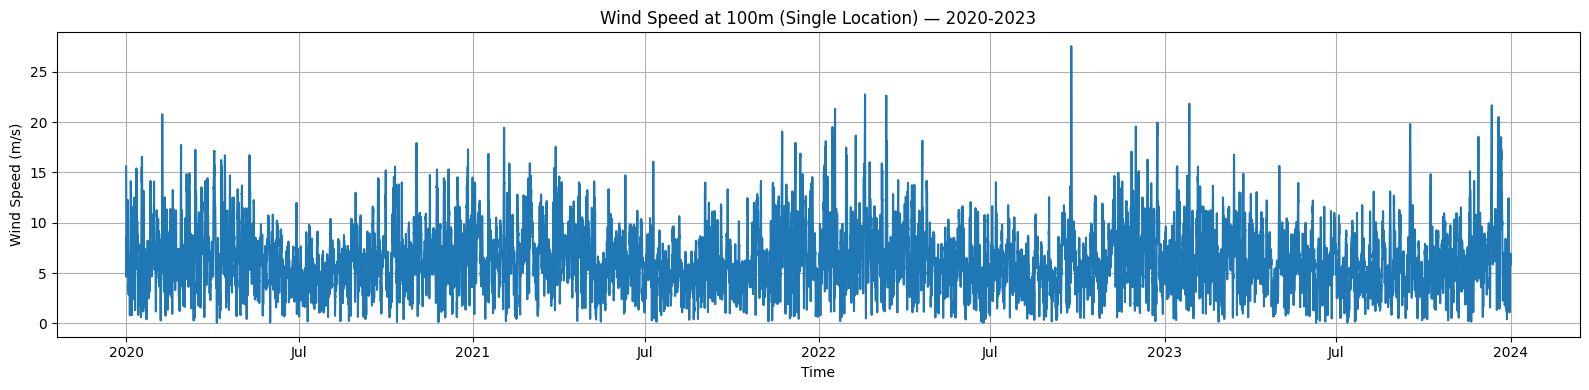

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_100m'].sel(latitude=45, longitude=-63)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 100m (Single Location) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

Furthest North

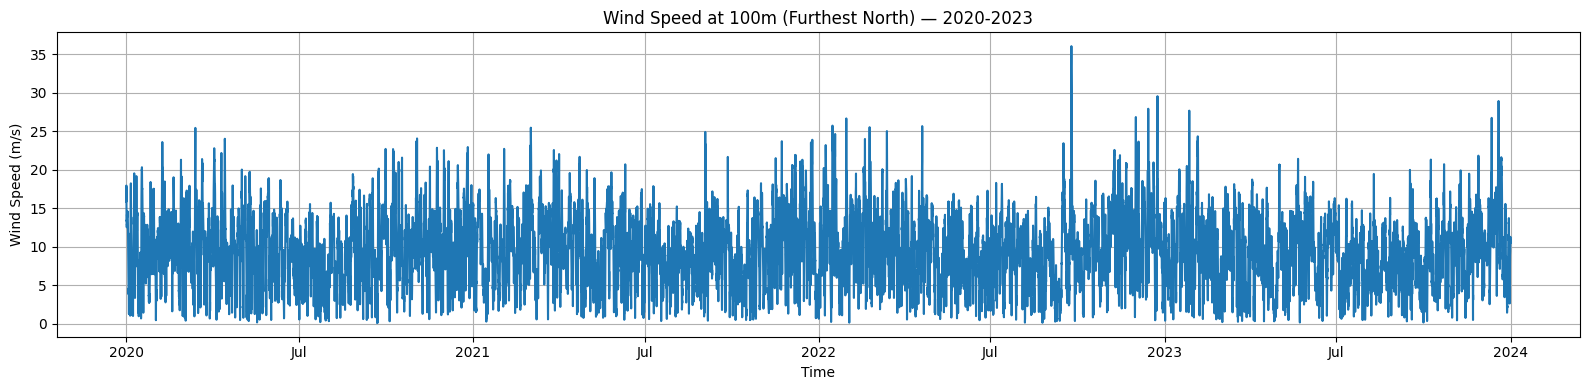

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_100m'].sel(latitude=47, longitude=-64)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 100m (Furthest North) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

Furthest West

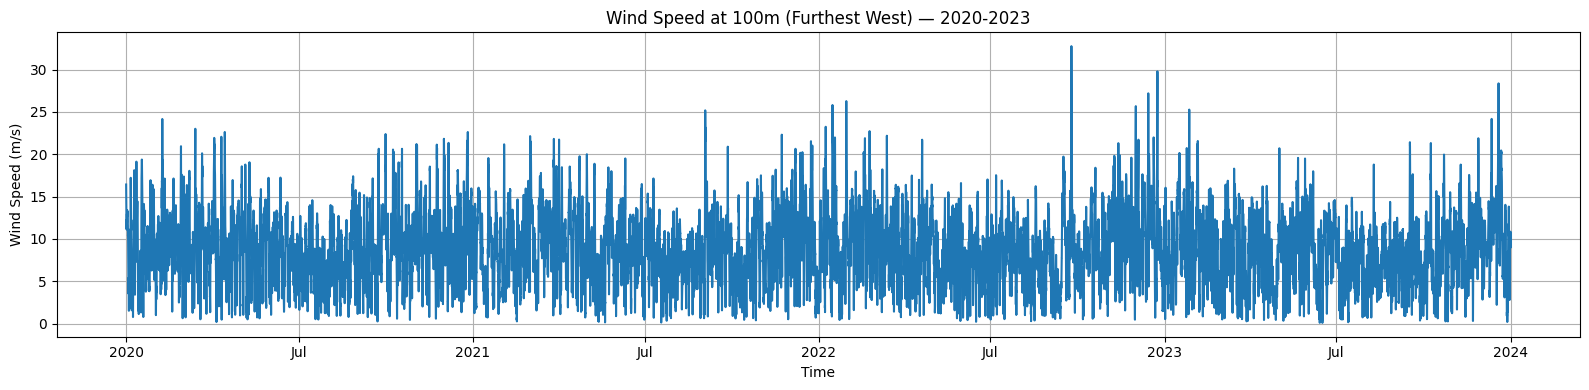

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_100m'].sel(latitude=46.75, longitude=-64.5)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 100m (Furthest West) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

Furthest South

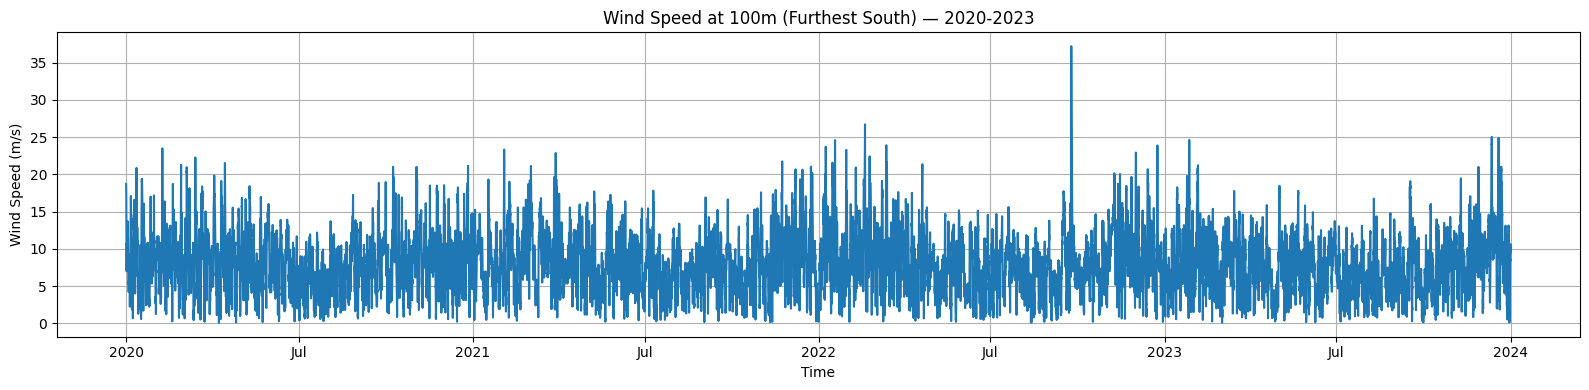

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_100m'].sel(latitude=46, longitude=-62.75)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 100m (Furthest South) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

Furthest East

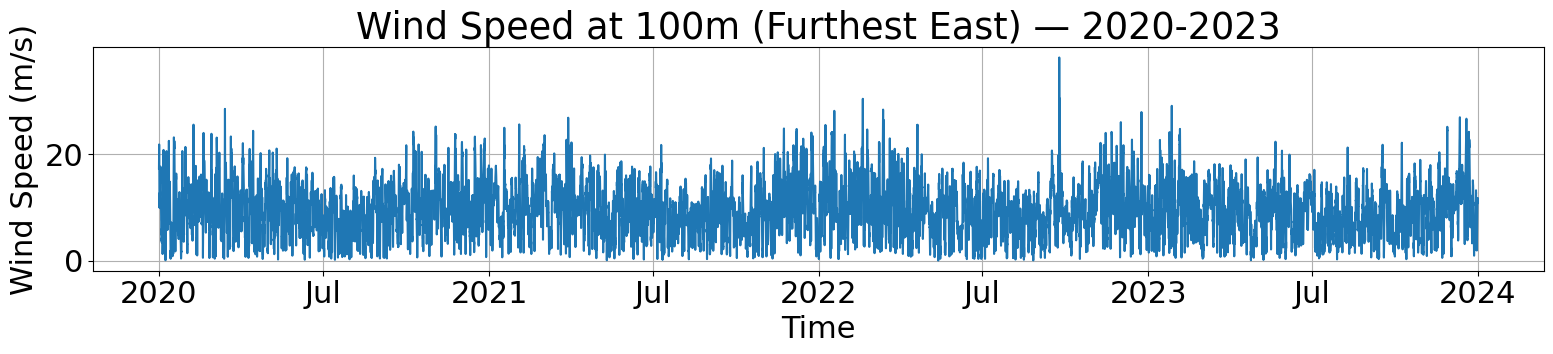

In [ ]:
plt.rcParams['font.size'] = 22

# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_100m'].sel(latitude=46.5, longitude=-62)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 100m (Furthest East) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/wind100-east.eps", format='eps')
plt.show()

#plt.savefig("/content/drive/MyDrive/Colab Notebooks/wind100-east.pdf", format='pdf')

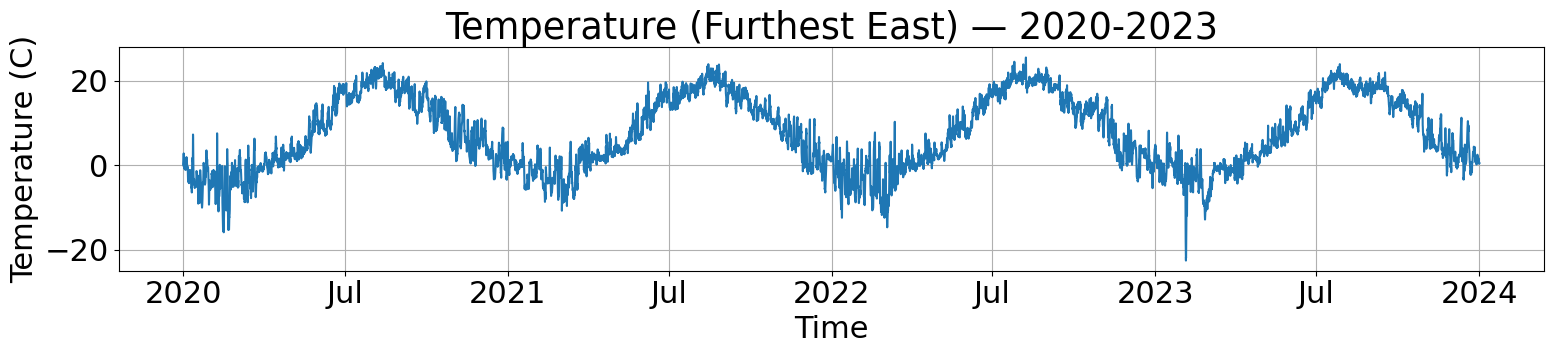

In [ ]:
plt.rcParams['font.size'] = 22

# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['temp_C'].sel(latitude=46.5, longitude=-62)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Temperature (Furthest East) — 2020-2023")
plt.ylabel("Temperature (C)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/temperature-east.eps", format='eps')
plt.show()



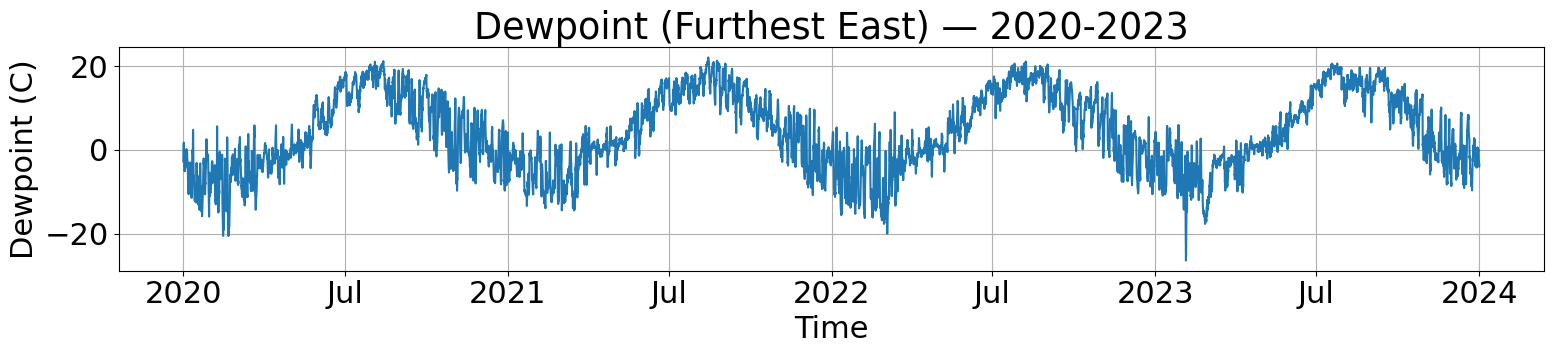

In [ ]:
plt.rcParams['font.size'] = 22

# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['dewpoint_C'].sel(latitude=46.5, longitude=-62)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Dewpoint (Furthest East) — 2020-2023")
plt.ylabel("Dewpoint (C)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/dewpoint-east.eps", format='eps')
plt.show()



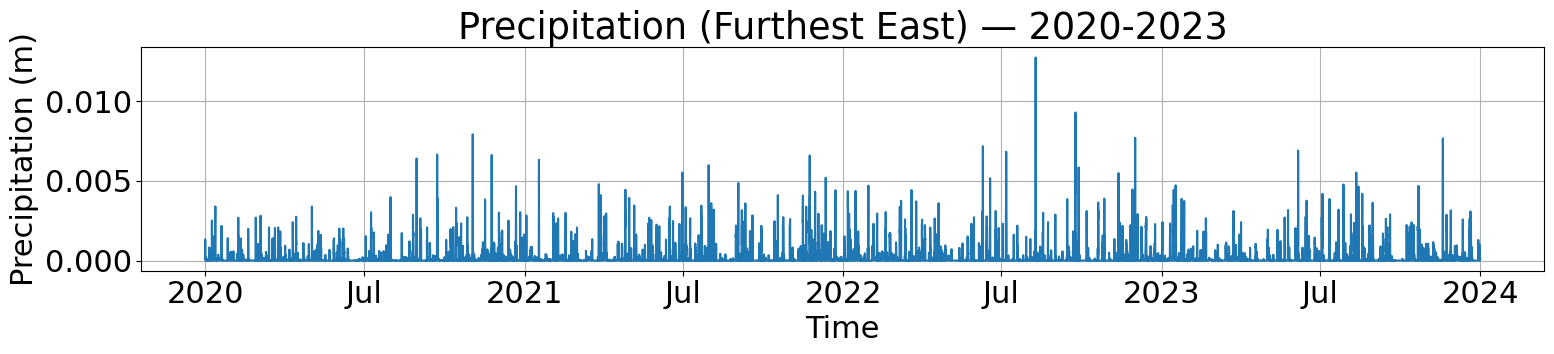

In [ ]:
plt.rcParams['font.size'] = 22

# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['tp'].sel(latitude=46.5, longitude=-62)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Precipitation (Furthest East) — 2020-2023")
plt.ylabel("Precipitation (m)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/precipitation-east.eps", format='eps')
plt.show()



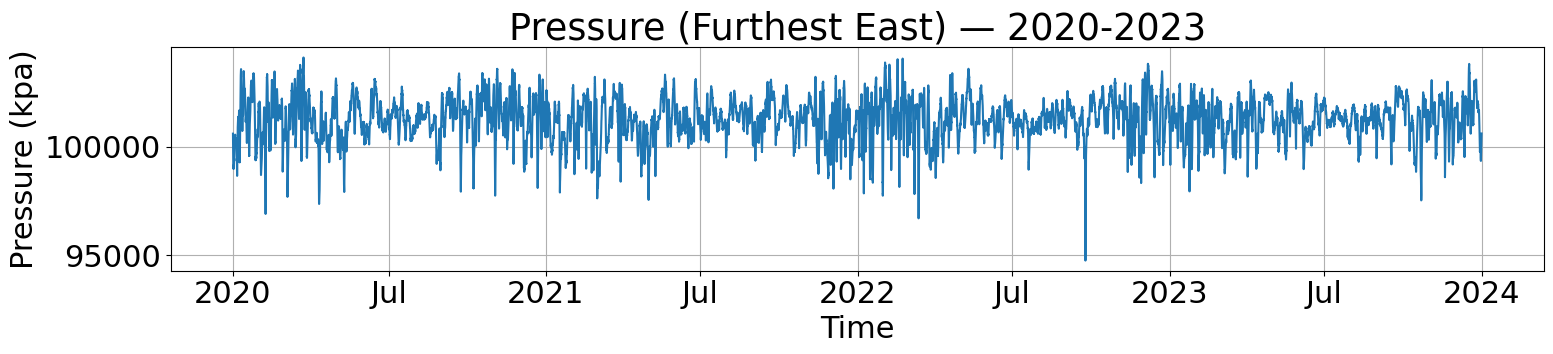

In [ ]:
plt.rcParams['font.size'] = 22

# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['sp'].sel(latitude=46.5, longitude=-62)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Pressure (Furthest East) — 2020-2023")
plt.ylabel("Pressure (kpa)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/pressure-east.eps", format='eps')
plt.show()



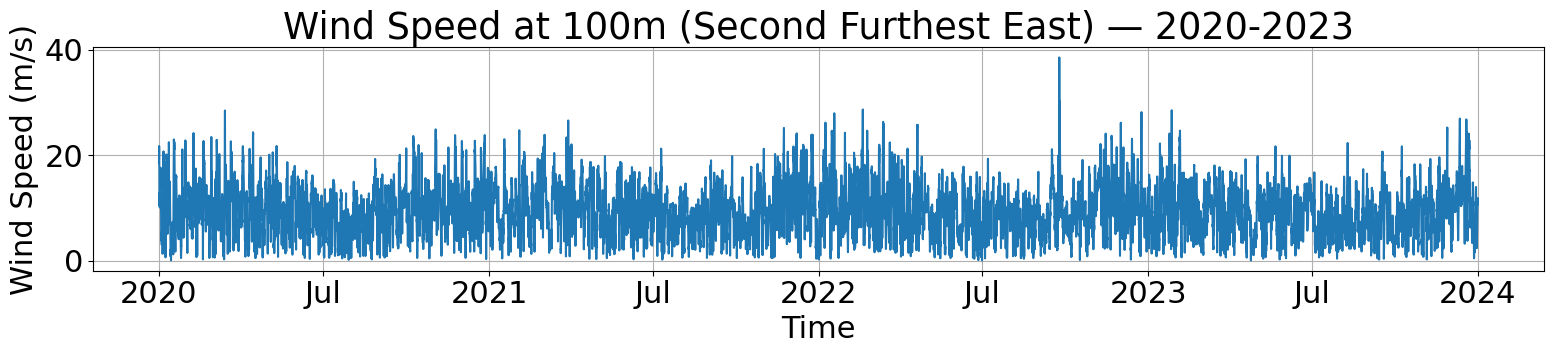

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_100m'].sel(latitude=46.5, longitude=-62.25)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 100m (Second Furthest East) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

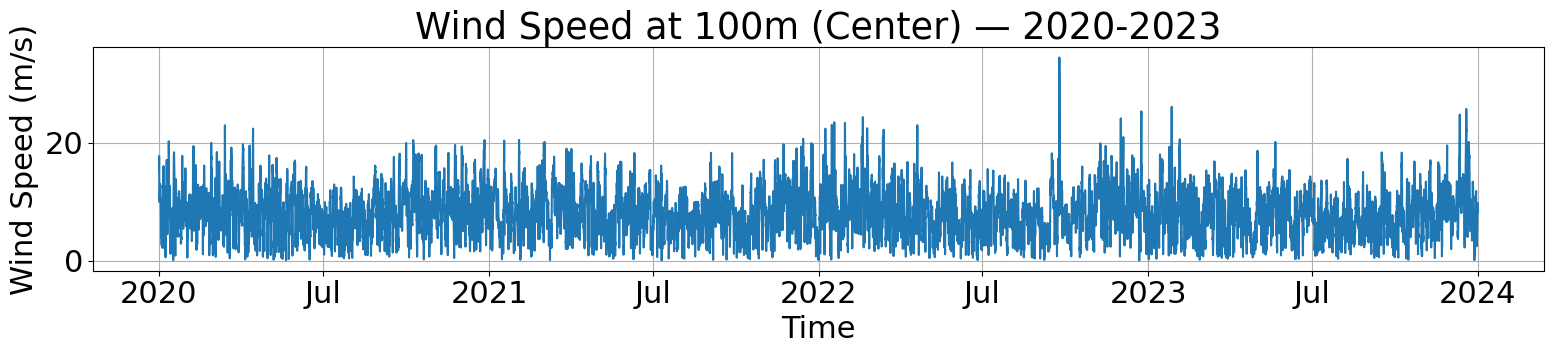

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_100m'].sel(latitude=46.5, longitude=-63.75)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 100m (Center) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

10 m

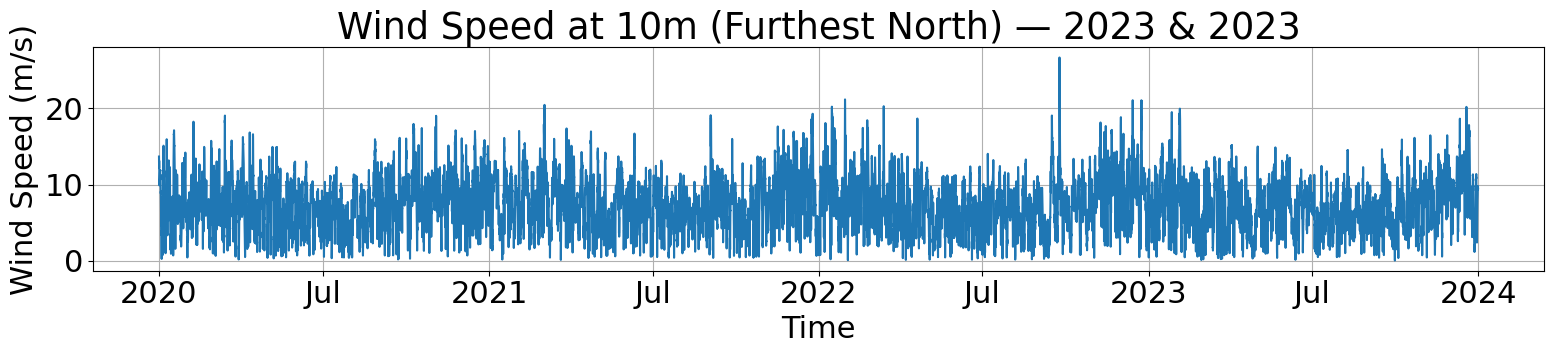

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_10m'].sel(latitude=47, longitude=-64)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 10m (Furthest North) — 2023 & 2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

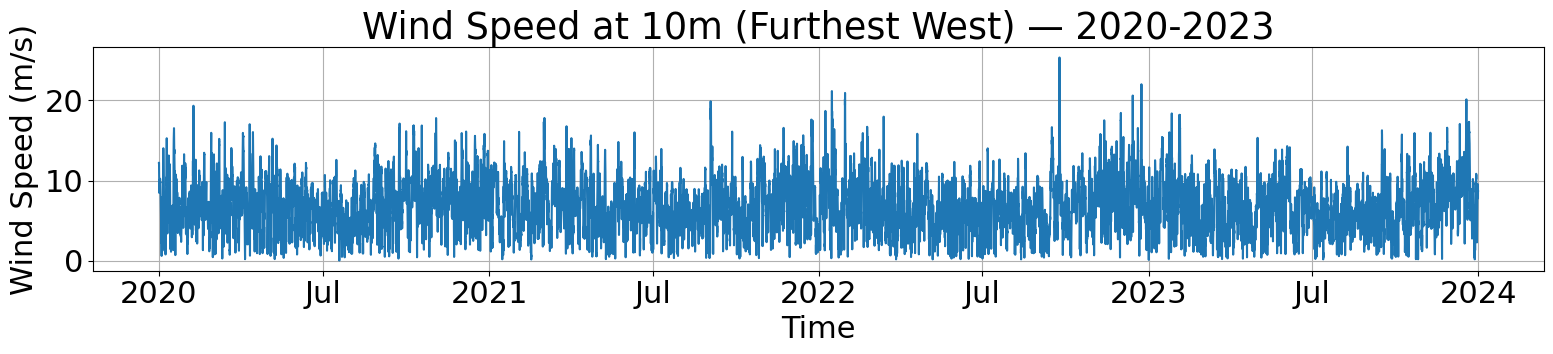

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_10m'].sel(latitude=46.75, longitude=-64.5)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 10m (Furthest West) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

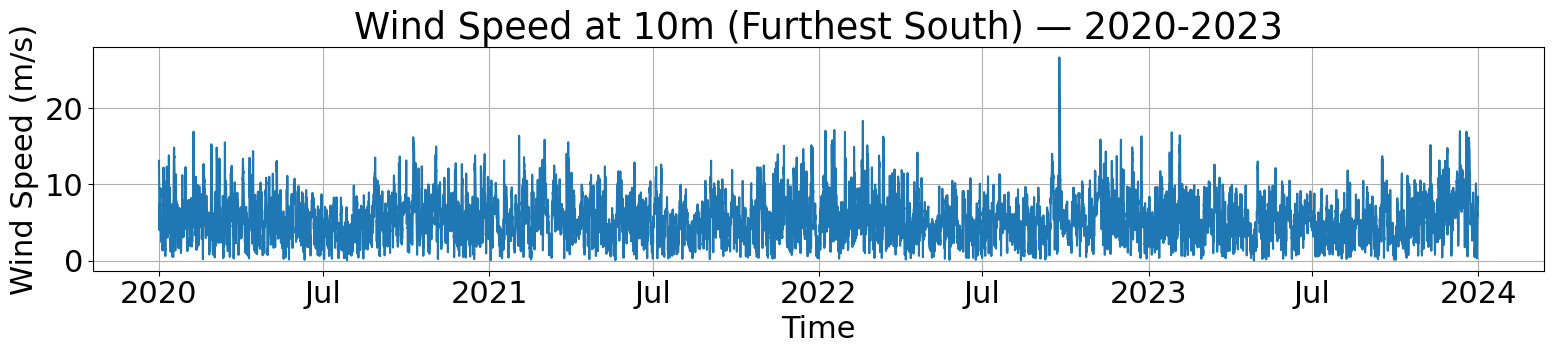

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_10m'].sel(latitude=46, longitude=-62.75)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 10m (Furthest South) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

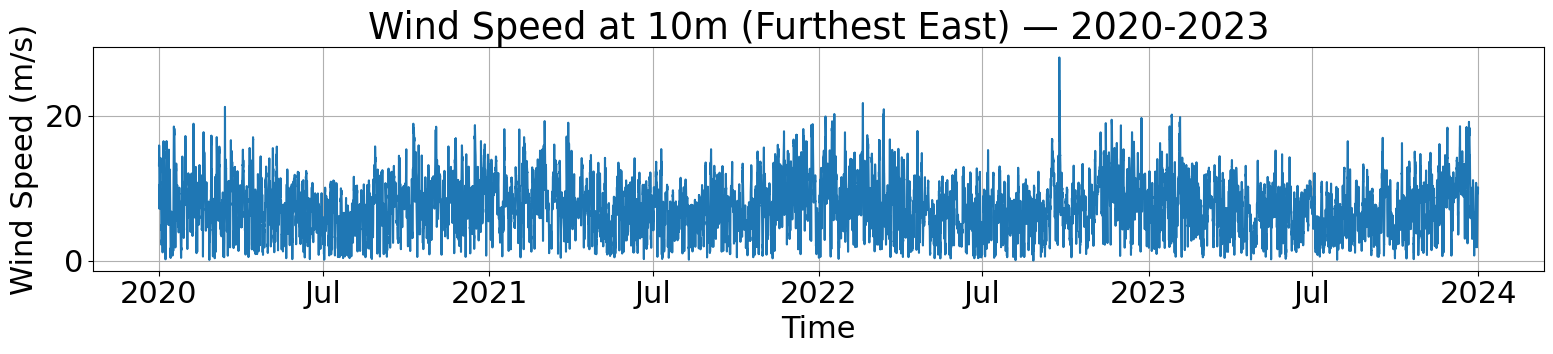

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_10m'].sel(latitude=46.5, longitude=-62)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 10m (Furthest East) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

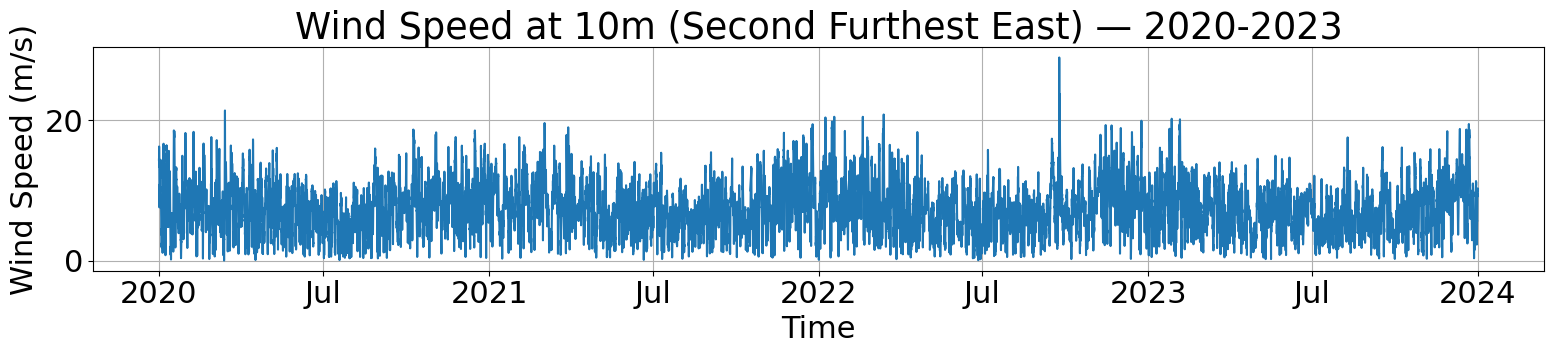

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_10m'].sel(latitude=46.5, longitude=-62.25)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 10m (Second Furthest East) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

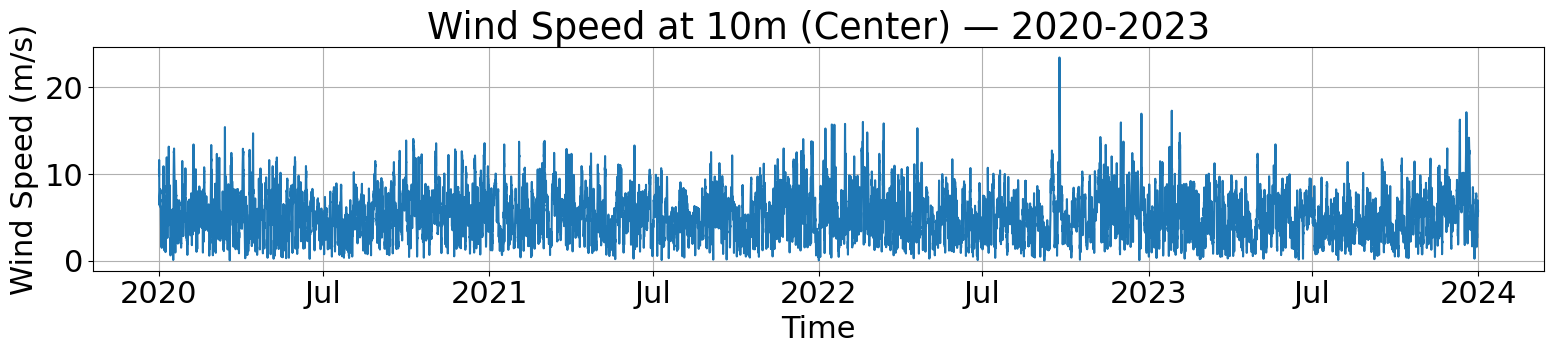

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined202023['wind_speed_10m'].sel(latitude=46.5, longitude=-63.75)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 10m (Center) — 2020-2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

#Pre-processing

###Adding time features

In [ ]:
combined202023["hour"] = combined202023["valid_time"].dt.hour
combined202023["month"] = combined202023["valid_time"].dt.month
combined202023["dayofyear"] = combined202023["valid_time"].dt.dayofyear
combined202023["year"] = combined202023["valid_time"].dt.year

In [ ]:
print(combined202023)

<xarray.Dataset> Size: 374MB
Dimensions:          (valid_time: 35064, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 281kB 2020-01-01 ... 2023-12...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 561kB '0001' '0001' ... '0001' '0001'
Data variables: (12/16)
    u10              (valid_time, latitude, longitude) float32 31MB -10.61 .....
    v10              (valid_time, latitude, longitude) float32 31MB -0.01851 ...
    wind_speed_10m   (valid_time, latitude, longitude) float32 31MB 10.61 ......
    u100             (valid_time, latitude, longitude) float32 31MB -14.22 .....
    v100             (valid_time, latitude, longitude) float32 31MB 0.3263 .....
    wind_speed_100m  (valid_time, latitude, longitude) float32 31MB 14.22 ......
    ...               ...
    tp

In [ ]:
combined202023

<xarray.Dataset> Size: 374MB
Dimensions:          (valid_time: 35064, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 281kB 2020-01-01 ... 2023-12...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 561kB '0001' '0001' ... '0001' '0001'
Data variables: (12/16)
    u10              (valid_time, latitude, longitude) float32 31MB -10.61 .....
    v10              (valid_time, latitude, longitude) float32 31MB -0.01851 ...
    wind_speed_10m   (valid_time, latitude, longitude) float32 31MB 10.61 ......
    u100             (valid_time, latitude, longitude) float32 31MB -14.22 .....
    v100             (valid_time, latitude, longitude) float32 31MB 0.3263 .....
    wind_speed_100m  (valid_time, latitude, longitude) float32 31MB 14.22 ......
    ...               ...
    tp               (valid_time, latitude, longitude) float32 31MB 0.002068 ...
    sp               (valid_time, latitude, longitude) float32 31MB 9.988e+04...
    hour             (valid_time) int64 281kB 0 1 2 3 4 5 ... 18 19 20 21 22 23
    month            (valid_time) int64 281kB 1 1 1 1 1 1 ... 12 12 12 12 12 12
    dayofyear        (valid_time) int64 281kB 1 1 1 1 1 ... 365 365 365 365 365
    year             (valid_time) int64 281kB 2020 2020 2020 ... 2023 2023 2023
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-23T02:48 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
#combined2023["hour"] = combined2023["valid_time"].dt.hour
#combined2023["month"] = combined2023["valid_time"].dt.month
#combined2023["dayofyear"] = combined2023["valid_time"].dt.dayofyear
#combined2023["year"] = combined2023["valid_time"].dt.year

In [ ]:
#print(combined2023)

In [ ]:
#combined2023

In [ ]:

combined2024["hour"] = combined2024["valid_time"].dt.hour
combined2024["month"] = combined2024["valid_time"].dt.month
combined2024["dayofyear"] = combined2024["valid_time"].dt.dayofyear
combined2024["year"] = combined2024["valid_time"].dt.year

In [ ]:
print(combined2024)

<xarray.Dataset> Size: 94MB
Dimensions:          (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables: (12/16)
    u10              (valid_time, latitude, longitude) float32 8MB 5.803 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB -4.287 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 7.215 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 6.755 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -5.264 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 8.564 ... ...
    ...               ...
    tp  

In [ ]:
combined2024

<xarray.Dataset> Size: 94MB
Dimensions:          (valid_time: 8784, latitude: 13, longitude: 17)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
  * latitude         (latitude) float64 104B 48.0 47.75 47.5 ... 45.5 45.25 45.0
  * longitude        (longitude) float64 136B -65.0 -64.75 ... -61.25 -61.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables: (12/16)
    u10              (valid_time, latitude, longitude) float32 8MB 5.803 ... ...
    v10              (valid_time, latitude, longitude) float32 8MB -4.287 ......
    wind_speed_10m   (valid_time, latitude, longitude) float32 8MB 7.215 ... ...
    u100             (valid_time, latitude, longitude) float32 8MB 6.755 ... ...
    v100             (valid_time, latitude, longitude) float32 8MB -5.264 ......
    wind_speed_100m  (valid_time, latitude, longitude) float32 8MB 8.564 ... ...
    ...               ...
    tp               (valid_time, latitude, longitude) float32 8MB ...
    sp               (valid_time, latitude, longitude) float32 8MB ...
    hour             (valid_time) int64 70kB 0 1 2 3 4 5 6 ... 18 19 20 21 22 23
    month            (valid_time) int64 70kB 1 1 1 1 1 1 1 ... 12 12 12 12 12 12
    dayofyear        (valid_time) int64 70kB 1 1 1 1 1 1 ... 366 366 366 366 366
    year             (valid_time) int64 70kB 2024 2024 2024 ... 2024 2024 2024
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-21T22:37 GRIB to CDM+CF via cfgrib-0.9.1...

###Flattening for location(47,64)

In [ ]:
combined2020234764 = combined202023.sel(latitude=47.0, longitude=-64.0, method="nearest")

In [ ]:
print(combined2020234764)

<xarray.Dataset> Size: 4MB
Dimensions:          (valid_time: 35064)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 281kB 2020-01-01 ... 2023-12...
    latitude         float64 8B 47.0
    longitude        float64 8B -64.0
    expver           (valid_time) <U4 561kB '0001' '0001' ... '0001' '0001'
Data variables: (12/16)
    u10              (valid_time) float32 140kB -13.54 -13.04 ... 7.377 7.252
    v10              (valid_time) float32 140kB 1.992 2.769 ... -6.139 -6.167
    wind_speed_10m   (valid_time) float32 140kB 13.68 13.33 13.02 ... 9.598 9.52
    u100             (valid_time) float32 140kB -17.48 -16.61 ... 8.226 8.145
    v100             (valid_time) float32 140kB 2.817 3.736 ... -7.102 -7.128
    wind_speed_100m  (valid_time) float32 140kB 17.7 17.02 16.47 ... 10.87 10.82
    ...               ...
    tp               (valid_time) float32 140kB 0.002824 0.002071 ... 6.676e-06
    sp               (valid_time) float32 140kB 1.0

In [ ]:
combined20234764 = combined2024.sel(latitude=47.0, longitude=-64.0, method="nearest")

In [ ]:
print(combined20234764)

<xarray.Dataset> Size: 914kB
Dimensions:          (valid_time: 8784)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
    latitude         float64 8B 47.0
    longitude        float64 8B -64.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables: (12/16)
    u10              (valid_time) float32 35kB 7.364 7.353 7.195 ... 5.95 6.347
    v10              (valid_time) float32 35kB -6.279 -6.333 ... 3.483 2.825
    wind_speed_10m   (valid_time) float32 35kB 9.677 9.704 9.636 ... 6.894 6.948
    u100             (valid_time) float32 35kB 8.27 8.251 8.024 ... 9.248 9.523
    v100             (valid_time) float32 35kB -7.246 -7.3 -7.36 ... 4.145 3.236
    wind_speed_100m  (valid_time) float32 35kB 11.0 11.02 10.89 ... 10.13 10.06
    ...               ...
    tp               (valid_time) float32 35kB ...
    sp               (valid_time) float32 35kB ...
    hour             (v

In [ ]:
combined20244764 = combined2024.sel(latitude=47.0, longitude=-64.0, method="nearest")

In [ ]:
print(combined20244764)

<xarray.Dataset> Size: 914kB
Dimensions:          (valid_time: 8784)
Coordinates:
    number           int64 8B 0
  * valid_time       (valid_time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-...
    latitude         float64 8B 47.0
    longitude        float64 8B -64.0
    expver           (valid_time) <U4 141kB '0001' '0001' ... '0001' '0001'
Data variables: (12/16)
    u10              (valid_time) float32 35kB 7.364 7.353 7.195 ... 5.95 6.347
    v10              (valid_time) float32 35kB -6.279 -6.333 ... 3.483 2.825
    wind_speed_10m   (valid_time) float32 35kB 9.677 9.704 9.636 ... 6.894 6.948
    u100             (valid_time) float32 35kB 8.27 8.251 8.024 ... 9.248 9.523
    v100             (valid_time) float32 35kB -7.246 -7.3 -7.36 ... 4.145 3.236
    wind_speed_100m  (valid_time) float32 35kB 11.0 11.02 10.89 ... 10.13 10.06
    ...               ...
    tp               (valid_time) float32 35kB ...
    sp               (valid_time) float32 35kB ...
    hour             (v

###Turning to dataframe

In [ ]:
df = combined2020234764.to_dataframe().reset_index()

In [ ]:
df

,valid_time,u10,v10,wind_speed_10m,u100,v100,wind_speed_100m,d2m,t2m,temp_C,...,tp,sp,number,latitude,longitude,expver,hour,month,dayofyear,year
0,2020-01-01 00:00:00,-13.537231,1.992233,13.683042,-17.477737,2.817474,17.703375,270.922363,272.389771,-0.760223,...,0.002824,100353.4375,0,47.0,-64.0,0001,0,1,1,2020
1,2020-01-01 01:00:00,-13.035828,2.768707,13.326611,-16.608490,3.735565,17.023407,271.096802,272.472656,-0.677338,...,0.002071,100184.5625,0,47.0,-64.0,0001,1,1,1,2020
2,2020-01-01 02:00:00,-12.592575,3.294403,13.016376,-15.882782,4.357422,16.469666,271.438599,272.674805,-0.475189,...,0.001458,100020.0625,0,47.0,-64.0,0001,2,1,1,2020
3,2020-01-01 03:00:00,-11.727051,3.227448,12.163065,-15.068130,4.815125,15.818786,271.891724,273.007324,-0.142670,...,0.001046,99779.5625,0,47.0,-64.0,0001,3,1,1,2020
4,2020-01-01 04:00:00,-11.527435,5.766937,12.889504,-14.681274,8.497620,16.963177,272.413696,273.542114,0.392120,...,0.000733,99518.6250,0,47.0,-64.0,0001,4,1,1,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2023-12-31 19:00:00,7.796509,-5.072617,9.301451,8.725128,-5.798309,10.476080,267.524170,272.497437,-0.652557,...,0.000002,100543.7500,0,47.0,-64.0,0001,19,12,365,2023
35060,2023-12-31 20:00:00,7.929657,-4.961594,9.353976,8.881119,-5.682739,10.543613,267.258423,272.577637,-0.572357,...,0.000006,100666.6875,0,47.0,-64.0,0001,20,12,365,2023
35061,2023-12-31 21:00:00,7.863205,-5.040878,9.340260,8.798874,-5.773956,10.524199,267.086060,272.577881,-0.572113,...,0.000008,100714.3750,0,47.0,-64.0,0001,21,12,365,2023
35062,2023-12-31 22:00:00,7.377197,-6.139496,9.597732,8.226486,-7.102417,10.868275,267.471680,273.442627,0.292633,...,0.000008,100766.8750,0,47.0,-64.0,0001,22,12,365,2023


In [ ]:
df_val = combined20234764.to_dataframe().reset_index()

In [ ]:
df_val

,valid_time,u10,v10,number,latitude,longitude,expver,wind_speed_10m,u100,v100,...,d2m,t2m,temp_C,dewpoint_C,tp,sp,hour,month,dayofyear,year
0,2024-01-01 00:00:00,7.364044,-6.278641,0,47.0,-64.0,0001,9.677318,8.269684,-7.246033,...,267.587524,273.077637,-0.072357,-5.562469,4.768372e-06,100891.6250,0,1,1,2024
1,2024-01-01 01:00:00,7.352982,-6.333115,0,47.0,-64.0,0001,9.704364,8.251404,-7.299835,...,267.598267,272.767700,-0.382294,-5.551727,3.814697e-06,100902.8125,1,1,1,2024
2,2024-01-01 02:00:00,7.194931,-6.410004,0,47.0,-64.0,0001,9.636139,8.023575,-7.360199,...,267.622070,272.410767,-0.739227,-5.527924,2.384186e-06,100957.8750,2,1,1,2024
3,2024-01-01 03:00:00,6.990158,-6.300186,0,47.0,-64.0,0001,9.410348,7.760559,-7.187027,...,267.395752,272.091309,-1.058685,-5.754242,9.536743e-07,100971.6250,3,1,1,2024
4,2024-01-01 04:00:00,6.740234,-5.919556,0,47.0,-64.0,0001,8.970613,7.391876,-6.690170,...,267.136475,271.819336,-1.330658,-6.013519,4.768372e-07,101002.5625,4,1,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31 19:00:00,4.137939,4.808548,0,47.0,-64.0,0001,6.343869,6.825974,6.442917,...,275.666138,276.719604,3.569611,2.516144,0.000000e+00,100797.3750,19,12,366,2024
8780,2024-12-31 20:00:00,4.306351,4.348740,0,47.0,-64.0,0001,6.120146,7.110397,5.661331,...,275.534546,276.716187,3.566193,2.384552,0.000000e+00,100887.3125,20,12,366,2024
8781,2024-12-31 21:00:00,4.651855,4.196045,0,47.0,-64.0,0001,6.264707,7.568695,5.295349,...,275.312073,276.694336,3.544342,2.162079,0.000000e+00,100987.0625,21,12,366,2024
8782,2024-12-31 22:00:00,5.949615,3.483353,0,47.0,-64.0,0001,6.894321,9.247879,4.144989,...,275.106873,276.926575,3.776581,1.956879,0.000000e+00,101077.0625,22,12,366,2024


In [ ]:
df_test = combined20244764.to_dataframe().reset_index()

In [ ]:
df_test

,valid_time,u10,v10,number,latitude,longitude,expver,wind_speed_10m,u100,v100,...,d2m,t2m,temp_C,dewpoint_C,tp,sp,hour,month,dayofyear,year
0,2024-01-01 00:00:00,7.364044,-6.278641,0,47.0,-64.0,0001,9.677318,8.269684,-7.246033,...,267.587524,273.077637,-0.072357,-5.562469,4.768372e-06,100891.6250,0,1,1,2024
1,2024-01-01 01:00:00,7.352982,-6.333115,0,47.0,-64.0,0001,9.704364,8.251404,-7.299835,...,267.598267,272.767700,-0.382294,-5.551727,3.814697e-06,100902.8125,1,1,1,2024
2,2024-01-01 02:00:00,7.194931,-6.410004,0,47.0,-64.0,0001,9.636139,8.023575,-7.360199,...,267.622070,272.410767,-0.739227,-5.527924,2.384186e-06,100957.8750,2,1,1,2024
3,2024-01-01 03:00:00,6.990158,-6.300186,0,47.0,-64.0,0001,9.410348,7.760559,-7.187027,...,267.395752,272.091309,-1.058685,-5.754242,9.536743e-07,100971.6250,3,1,1,2024
4,2024-01-01 04:00:00,6.740234,-5.919556,0,47.0,-64.0,0001,8.970613,7.391876,-6.690170,...,267.136475,271.819336,-1.330658,-6.013519,4.768372e-07,101002.5625,4,1,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31 19:00:00,4.137939,4.808548,0,47.0,-64.0,0001,6.343869,6.825974,6.442917,...,275.666138,276.719604,3.569611,2.516144,0.000000e+00,100797.3750,19,12,366,2024
8780,2024-12-31 20:00:00,4.306351,4.348740,0,47.0,-64.0,0001,6.120146,7.110397,5.661331,...,275.534546,276.716187,3.566193,2.384552,0.000000e+00,100887.3125,20,12,366,2024
8781,2024-12-31 21:00:00,4.651855,4.196045,0,47.0,-64.0,0001,6.264707,7.568695,5.295349,...,275.312073,276.694336,3.544342,2.162079,0.000000e+00,100987.0625,21,12,366,2024
8782,2024-12-31 22:00:00,5.949615,3.483353,0,47.0,-64.0,0001,6.894321,9.247879,4.144989,...,275.106873,276.926575,3.776581,1.956879,0.000000e+00,101077.0625,22,12,366,2024


In [ ]:
df_test = df_test[df.columns]

In [ ]:
df_val = df_val[df.columns]

In [ ]:
df

,valid_time,u10,v10,wind_speed_10m,u100,v100,wind_speed_100m,d2m,t2m,temp_C,...,tp,sp,number,latitude,longitude,expver,hour,month,dayofyear,year
0,2020-01-01 00:00:00,-13.537231,1.992233,13.683042,-17.477737,2.817474,17.703375,270.922363,272.389771,-0.760223,...,0.002824,100353.4375,0,47.0,-64.0,0001,0,1,1,2020
1,2020-01-01 01:00:00,-13.035828,2.768707,13.326611,-16.608490,3.735565,17.023407,271.096802,272.472656,-0.677338,...,0.002071,100184.5625,0,47.0,-64.0,0001,1,1,1,2020
2,2020-01-01 02:00:00,-12.592575,3.294403,13.016376,-15.882782,4.357422,16.469666,271.438599,272.674805,-0.475189,...,0.001458,100020.0625,0,47.0,-64.0,0001,2,1,1,2020
3,2020-01-01 03:00:00,-11.727051,3.227448,12.163065,-15.068130,4.815125,15.818786,271.891724,273.007324,-0.142670,...,0.001046,99779.5625,0,47.0,-64.0,0001,3,1,1,2020
4,2020-01-01 04:00:00,-11.527435,5.766937,12.889504,-14.681274,8.497620,16.963177,272.413696,273.542114,0.392120,...,0.000733,99518.6250,0,47.0,-64.0,0001,4,1,1,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2023-12-31 19:00:00,7.796509,-5.072617,9.301451,8.725128,-5.798309,10.476080,267.524170,272.497437,-0.652557,...,0.000002,100543.7500,0,47.0,-64.0,0001,19,12,365,2023
35060,2023-12-31 20:00:00,7.929657,-4.961594,9.353976,8.881119,-5.682739,10.543613,267.258423,272.577637,-0.572357,...,0.000006,100666.6875,0,47.0,-64.0,0001,20,12,365,2023
35061,2023-12-31 21:00:00,7.863205,-5.040878,9.340260,8.798874,-5.773956,10.524199,267.086060,272.577881,-0.572113,...,0.000008,100714.3750,0,47.0,-64.0,0001,21,12,365,2023
35062,2023-12-31 22:00:00,7.377197,-6.139496,9.597732,8.226486,-7.102417,10.868275,267.471680,273.442627,0.292633,...,0.000008,100766.8750,0,47.0,-64.0,0001,22,12,365,2023


In [ ]:
df_test

,valid_time,u10,v10,wind_speed_10m,u100,v100,wind_speed_100m,d2m,t2m,temp_C,...,tp,sp,number,latitude,longitude,expver,hour,month,dayofyear,year
0,2024-01-01 00:00:00,7.364044,-6.278641,9.677318,8.269684,-7.246033,10.995120,267.587524,273.077637,-0.072357,...,4.768372e-06,100891.6250,0,47.0,-64.0,0001,0,1,1,2024
1,2024-01-01 01:00:00,7.352982,-6.333115,9.704364,8.251404,-7.299835,11.016953,267.598267,272.767700,-0.382294,...,3.814697e-06,100902.8125,0,47.0,-64.0,0001,1,1,1,2024
2,2024-01-01 02:00:00,7.194931,-6.410004,9.636139,8.023575,-7.360199,10.888080,267.622070,272.410767,-0.739227,...,2.384186e-06,100957.8750,0,47.0,-64.0,0001,2,1,1,2024
3,2024-01-01 03:00:00,6.990158,-6.300186,9.410348,7.760559,-7.187027,10.577317,267.395752,272.091309,-1.058685,...,9.536743e-07,100971.6250,0,47.0,-64.0,0001,3,1,1,2024
4,2024-01-01 04:00:00,6.740234,-5.919556,8.970613,7.391876,-6.690170,9.969865,267.136475,271.819336,-1.330658,...,4.768372e-07,101002.5625,0,47.0,-64.0,0001,4,1,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31 19:00:00,4.137939,4.808548,6.343869,6.825974,6.442917,9.386431,275.666138,276.719604,3.569611,...,0.000000e+00,100797.3750,0,47.0,-64.0,0001,19,12,366,2024
8780,2024-12-31 20:00:00,4.306351,4.348740,6.120146,7.110397,5.661331,9.088918,275.534546,276.716187,3.566193,...,0.000000e+00,100887.3125,0,47.0,-64.0,0001,20,12,366,2024
8781,2024-12-31 21:00:00,4.651855,4.196045,6.264707,7.568695,5.295349,9.237200,275.312073,276.694336,3.544342,...,0.000000e+00,100987.0625,0,47.0,-64.0,0001,21,12,366,2024
8782,2024-12-31 22:00:00,5.949615,3.483353,6.894321,9.247879,4.144989,10.134308,275.106873,276.926575,3.776581,...,0.000000e+00,101077.0625,0,47.0,-64.0,0001,22,12,366,2024


In [ ]:
df_val

,valid_time,u10,v10,wind_speed_10m,u100,v100,wind_speed_100m,d2m,t2m,temp_C,...,tp,sp,number,latitude,longitude,expver,hour,month,dayofyear,year
0,2024-01-01 00:00:00,7.364044,-6.278641,9.677318,8.269684,-7.246033,10.995120,267.587524,273.077637,-0.072357,...,4.768372e-06,100891.6250,0,47.0,-64.0,0001,0,1,1,2024
1,2024-01-01 01:00:00,7.352982,-6.333115,9.704364,8.251404,-7.299835,11.016953,267.598267,272.767700,-0.382294,...,3.814697e-06,100902.8125,0,47.0,-64.0,0001,1,1,1,2024
2,2024-01-01 02:00:00,7.194931,-6.410004,9.636139,8.023575,-7.360199,10.888080,267.622070,272.410767,-0.739227,...,2.384186e-06,100957.8750,0,47.0,-64.0,0001,2,1,1,2024
3,2024-01-01 03:00:00,6.990158,-6.300186,9.410348,7.760559,-7.187027,10.577317,267.395752,272.091309,-1.058685,...,9.536743e-07,100971.6250,0,47.0,-64.0,0001,3,1,1,2024
4,2024-01-01 04:00:00,6.740234,-5.919556,8.970613,7.391876,-6.690170,9.969865,267.136475,271.819336,-1.330658,...,4.768372e-07,101002.5625,0,47.0,-64.0,0001,4,1,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31 19:00:00,4.137939,4.808548,6.343869,6.825974,6.442917,9.386431,275.666138,276.719604,3.569611,...,0.000000e+00,100797.3750,0,47.0,-64.0,0001,19,12,366,2024
8780,2024-12-31 20:00:00,4.306351,4.348740,6.120146,7.110397,5.661331,9.088918,275.534546,276.716187,3.566193,...,0.000000e+00,100887.3125,0,47.0,-64.0,0001,20,12,366,2024
8781,2024-12-31 21:00:00,4.651855,4.196045,6.264707,7.568695,5.295349,9.237200,275.312073,276.694336,3.544342,...,0.000000e+00,100987.0625,0,47.0,-64.0,0001,21,12,366,2024
8782,2024-12-31 22:00:00,5.949615,3.483353,6.894321,9.247879,4.144989,10.134308,275.106873,276.926575,3.776581,...,0.000000e+00,101077.0625,0,47.0,-64.0,0001,22,12,366,2024


##Correlations

In [ ]:
correlation_matrix = df.corr()

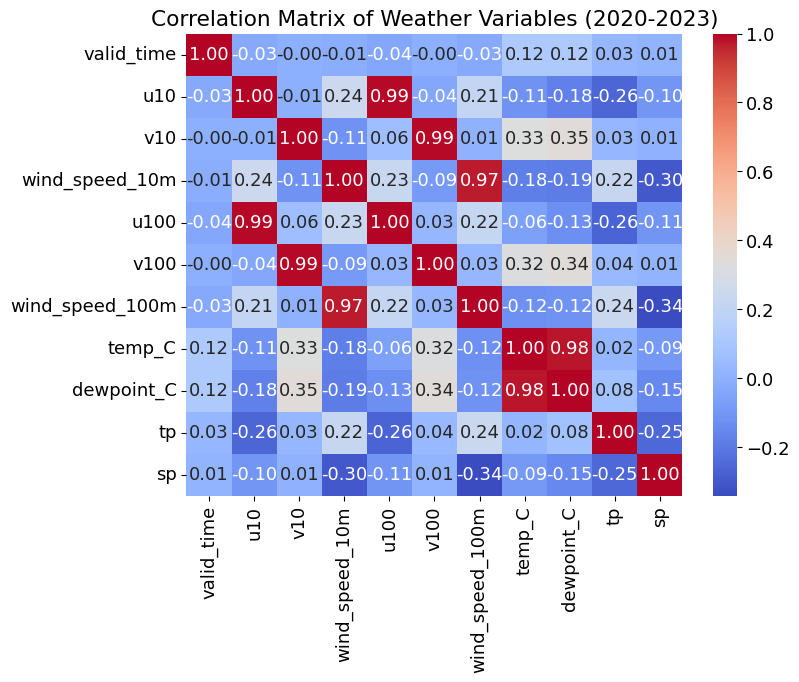

In [ ]:
plt.rcParams['font.size'] = 13

# List of variables you want to exclude
exclude_vars = ['number', 'latitude', 'longitude', 'expver', 'hour', 'month', 'dayofyear', 'year', 'd2m', 't2m']

# Drop them from the correlation matrix
filtered_corr = correlation_matrix.drop(index=exclude_vars, columns=exclude_vars)

# Now plot the filtered matrix
plt.figure(figsize=(8, 6))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Weather Variables (2020-2023)")
#plt.tick_params(axis='x', labelrotation=20)
#plt.tick_params(axis='y', labelrotation=20)
plt.show()

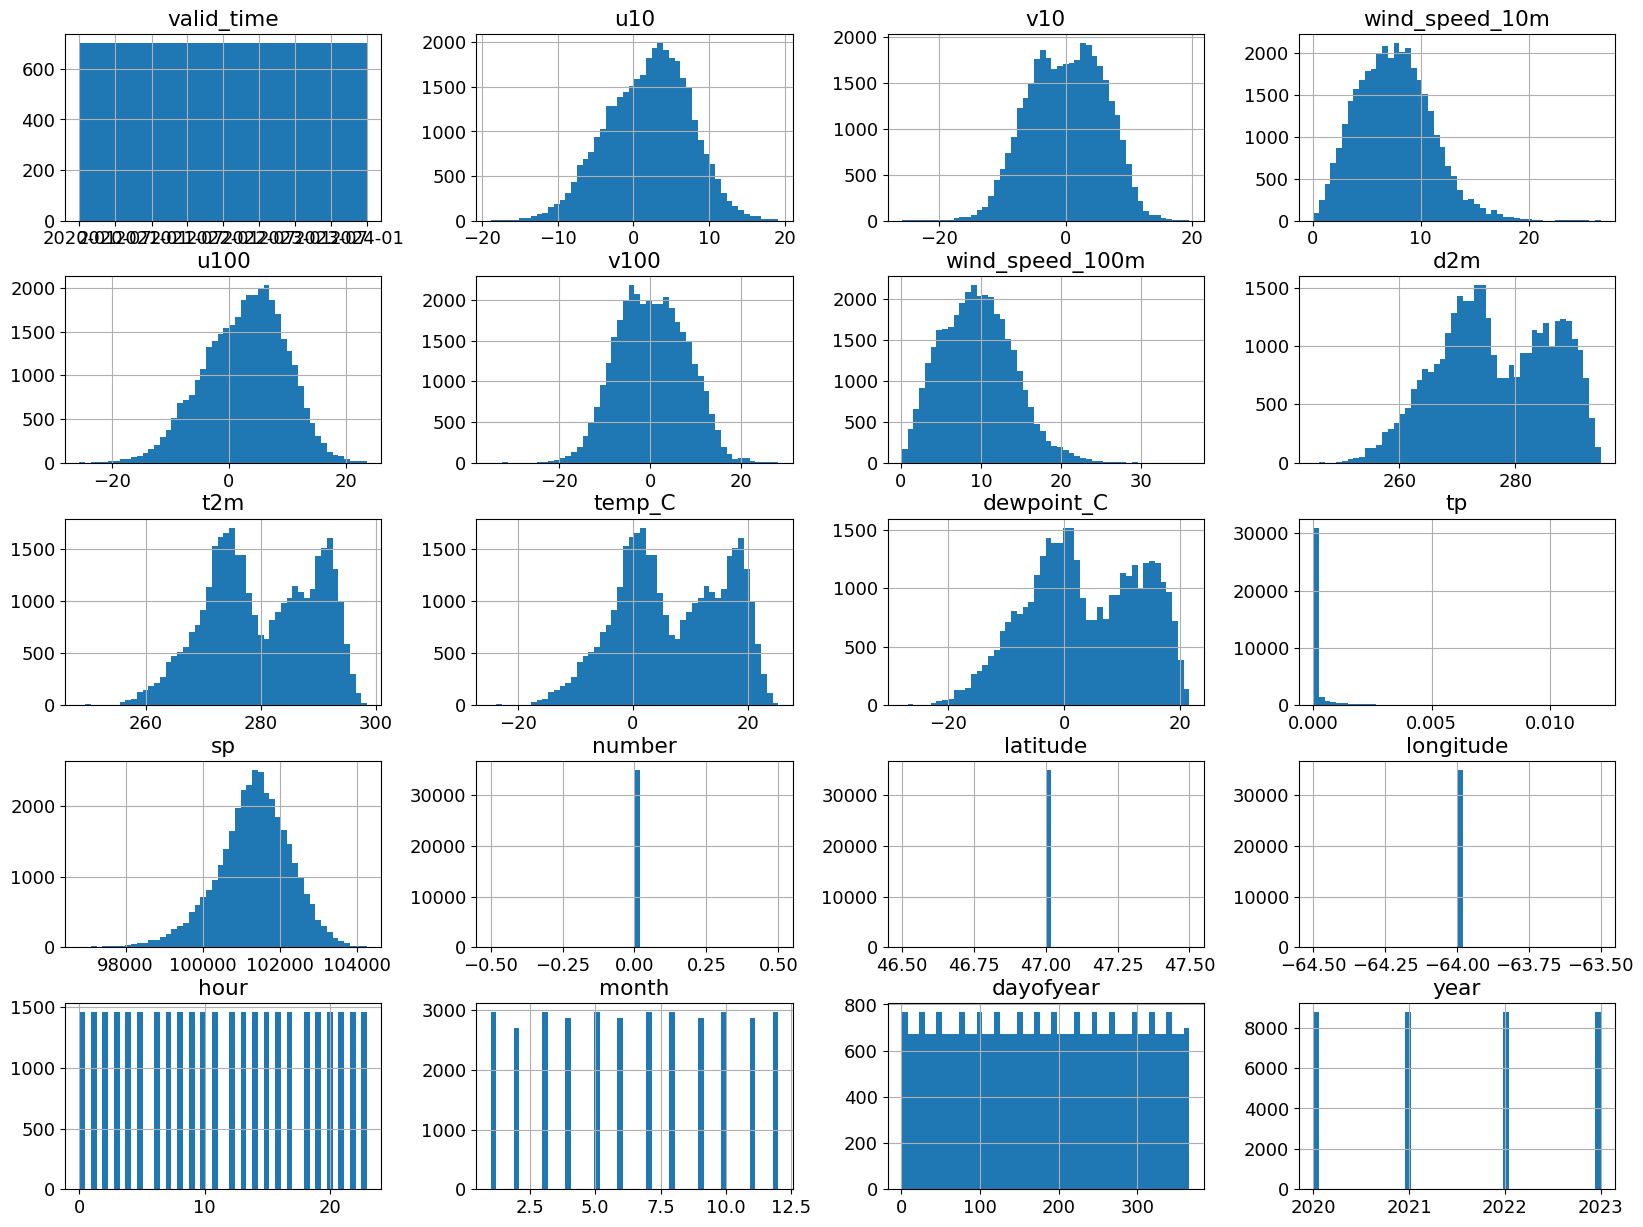

In [ ]:
df.hist(bins=50, figsize=(20,15))
plt.show()

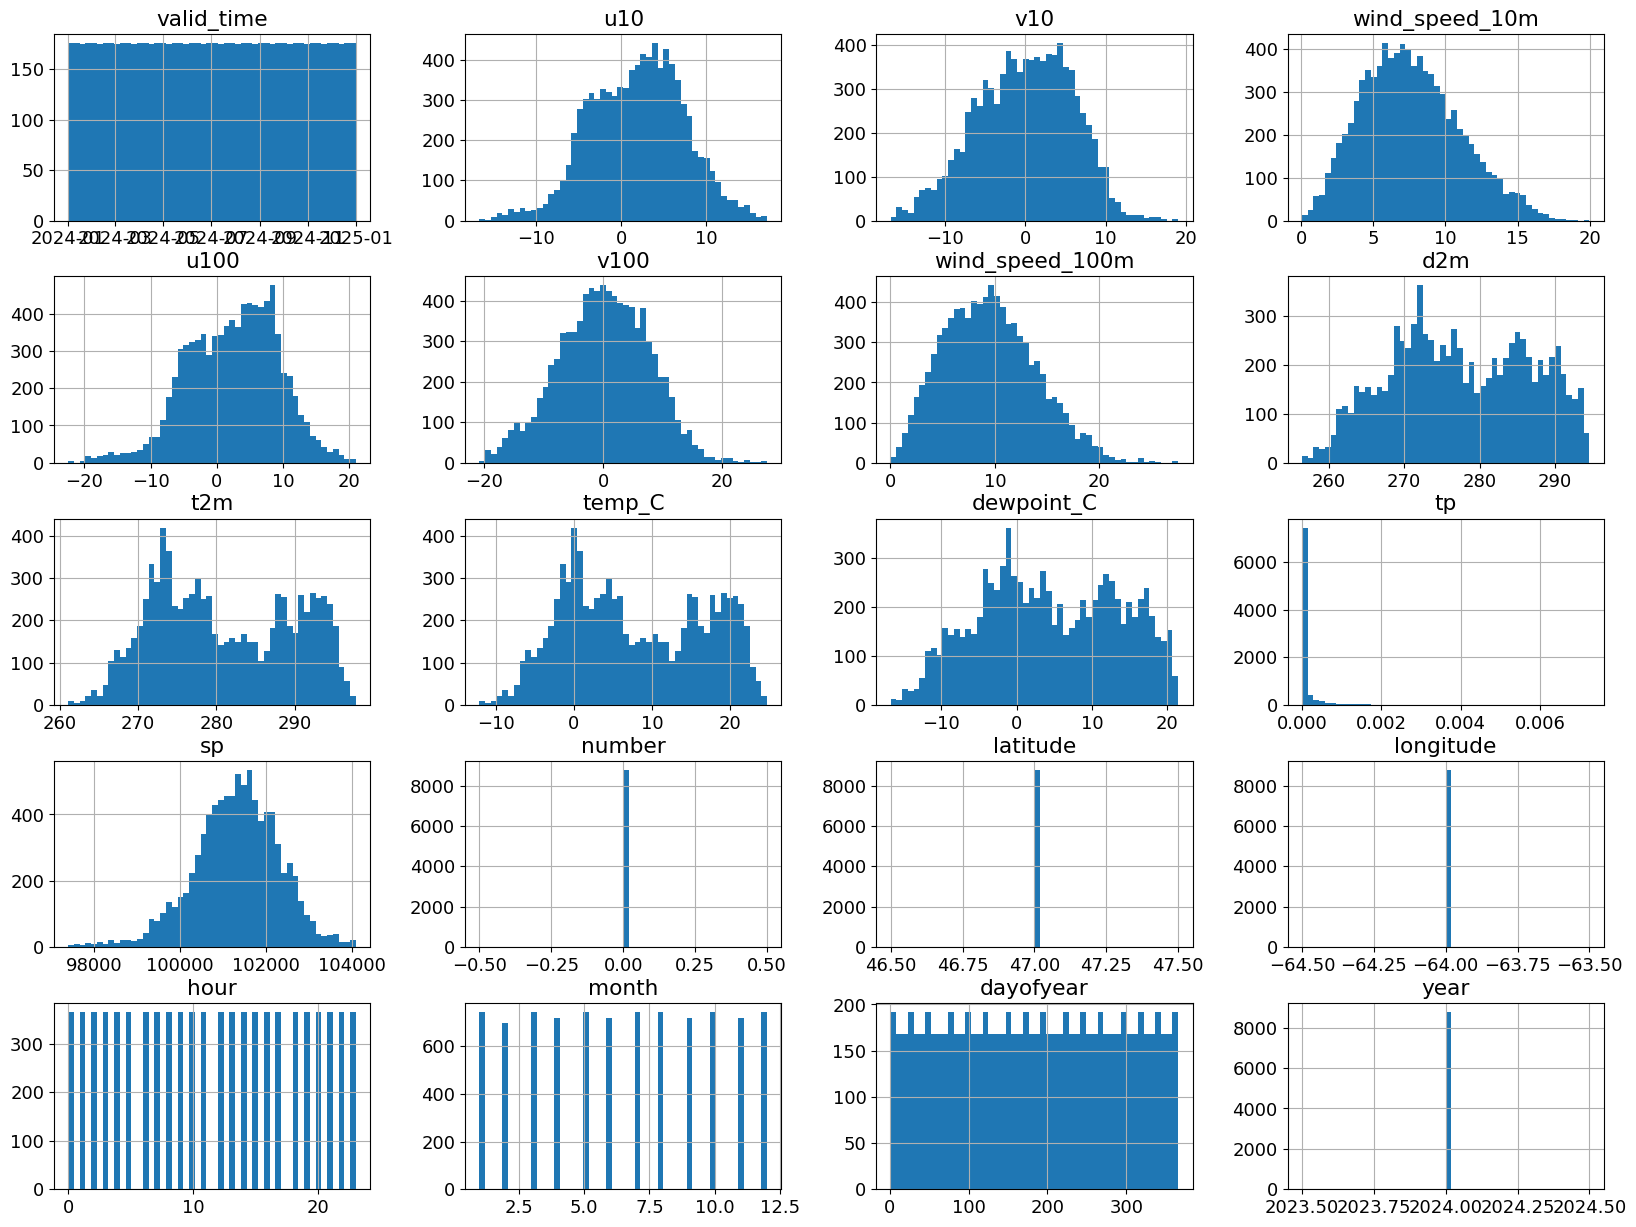

In [ ]:
df_val.hist(bins=50, figsize=(20,15))
plt.show()

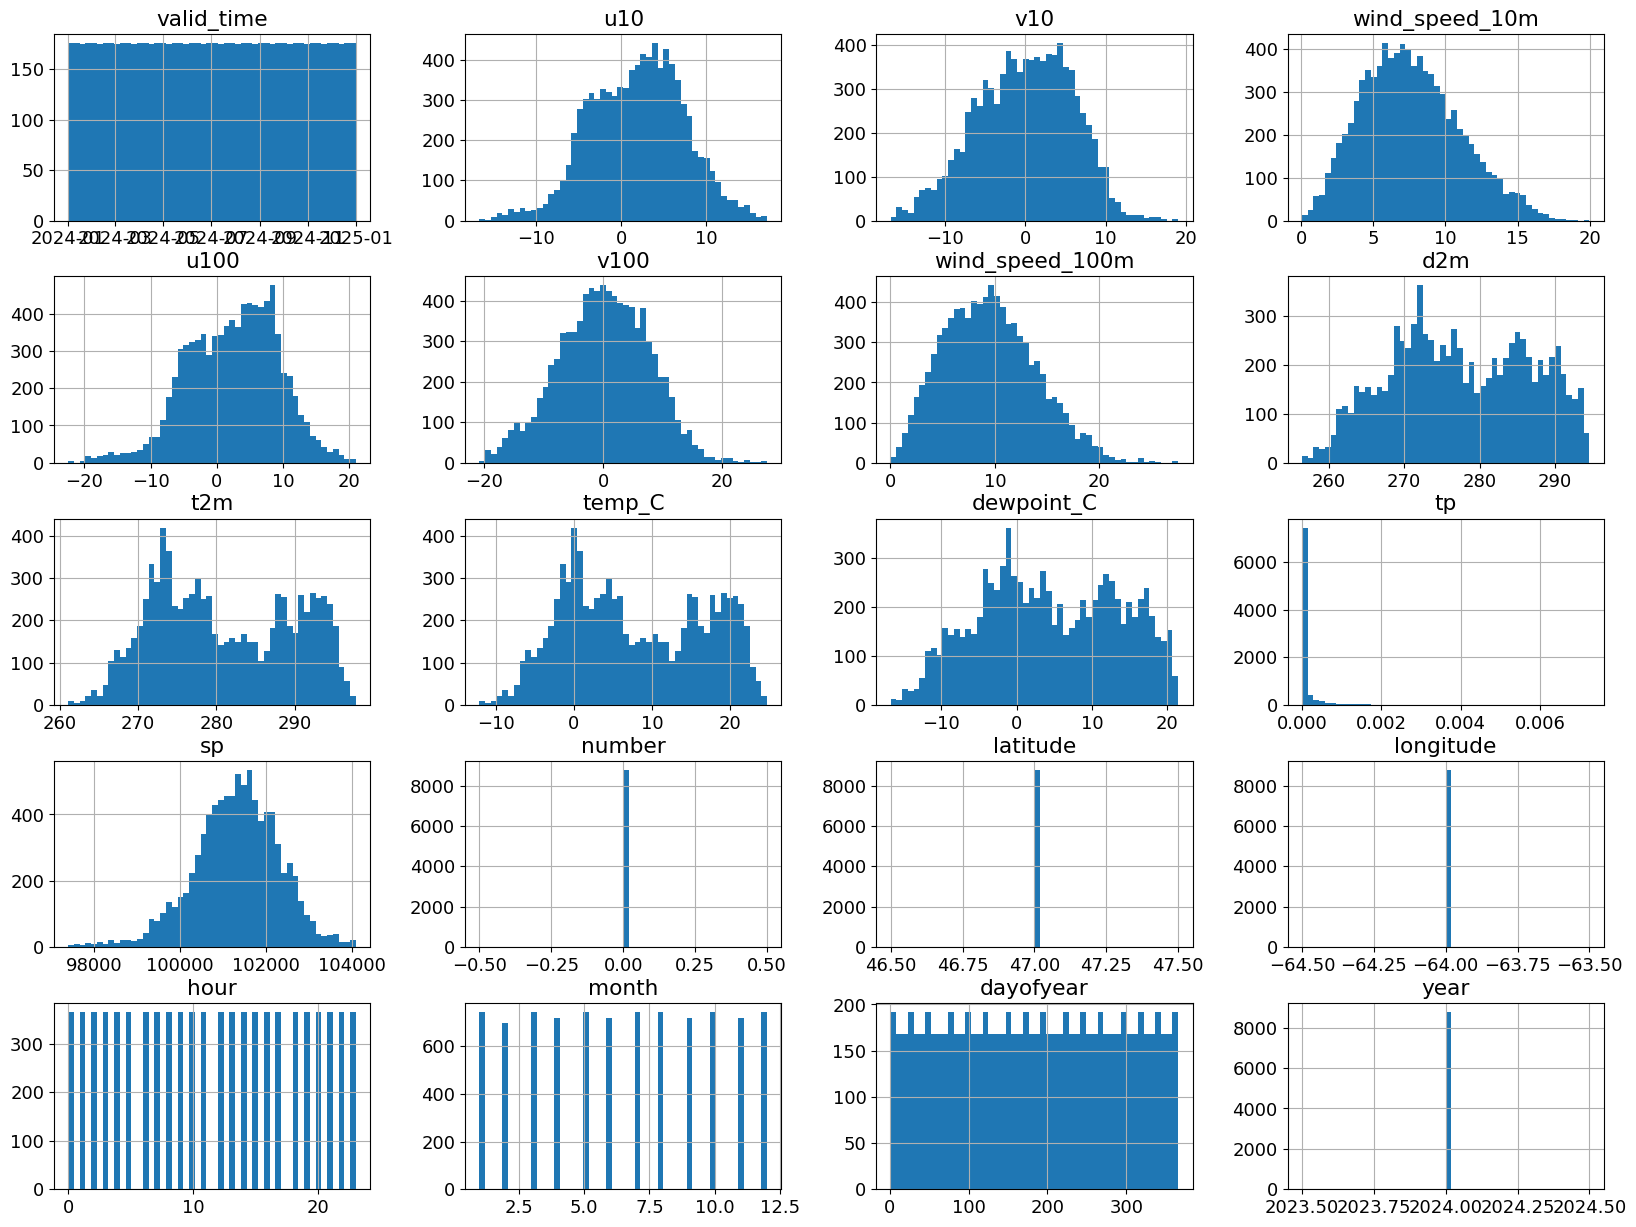

In [ ]:
df_test.hist(bins=50, figsize=(20,15))
plt.show()

##Preparing features and targets

###Train

In [ ]:
df = df.drop(columns=["v10", "v100", "valid_time"])

In [ ]:
df.columns

Index(['u10', 'wind_speed_10m', 'u100', 'wind_speed_100m', 'd2m', 't2m',
       'temp_C', 'dewpoint_C', 'tp', 'sp', 'number', 'latitude', 'longitude',
       'expver', 'hour', 'month', 'dayofyear', 'year'],
      dtype='object')

In [ ]:
target = df["wind_speed_100m"]  # this is your target

In [ ]:
print(target)

0        17.703375
1        17.023407
2        16.469666
3        15.818786
4        16.963177
           ...    
35059    10.476080
35060    10.543613
35061    10.524199
35062    10.868275
35063    10.823728
Name: wind_speed_100m, Length: 35064, dtype: float32


In [ ]:
features = df.drop(columns=["wind_speed_10m", "wind_speed_100m", "d2m", "t2m"])

In [ ]:
print(features)

             u10       u100    temp_C  dewpoint_C        tp           sp  \
0     -13.537231 -17.477737 -0.760223   -2.227631  0.002824  100353.4375   
1     -13.035828 -16.608490 -0.677338   -2.053192  0.002071  100184.5625   
2     -12.592575 -15.882782 -0.475189   -1.711395  0.001458  100020.0625   
3     -11.727051 -15.068130 -0.142670   -1.258270  0.001046   99779.5625   
4     -11.527435 -14.681274  0.392120   -0.736298  0.000733   99518.6250   
...          ...        ...       ...         ...       ...          ...   
35059   7.796509   8.725128 -0.652557   -5.625824  0.000002  100543.7500   
35060   7.929657   8.881119 -0.572357   -5.891571  0.000006  100666.6875   
35061   7.863205   8.798874 -0.572113   -6.063934  0.000008  100714.3750   
35062   7.377197   8.226486  0.292633   -5.678314  0.000008  100766.8750   
35063   7.252396   8.144806  0.091949   -5.438690  0.000007  100818.2500   

       number  latitude  longitude expver  hour  month  dayofyear  year  
0           0

###Validation

In [ ]:
df_val = df_val.drop(columns=["v10", "v100", "valid_time"])

In [ ]:
df_val.columns

Index(['u10', 'wind_speed_10m', 'u100', 'wind_speed_100m', 'd2m', 't2m',
       'temp_C', 'dewpoint_C', 'tp', 'sp', 'number', 'latitude', 'longitude',
       'expver', 'hour', 'month', 'dayofyear', 'year'],
      dtype='object')

In [ ]:
target_val = df_val["wind_speed_100m"]

In [ ]:
target_val

,wind_speed_100m
0,10.995120
1,11.016953
2,10.888080
3,10.577317
4,9.969865
...,...
8779,9.386431
8780,9.088918
8781,9.237200
8782,10.134308


In [ ]:
features_val = df_val.drop(columns=["wind_speed_10m", "wind_speed_100m", "d2m", "t2m"])

In [ ]:
features_val.columns

Index(['u10', 'u100', 'temp_C', 'dewpoint_C', 'tp', 'sp', 'number', 'latitude',
       'longitude', 'expver', 'hour', 'month', 'dayofyear', 'year'],
      dtype='object')

###Test

In [ ]:
df_test = df_test.drop(columns=["v10", "v100", "valid_time"])

In [ ]:
df_test.columns

Index(['u10', 'wind_speed_10m', 'u100', 'wind_speed_100m', 'd2m', 't2m',
       'temp_C', 'dewpoint_C', 'tp', 'sp', 'number', 'latitude', 'longitude',
       'expver', 'hour', 'month', 'dayofyear', 'year'],
      dtype='object')

In [ ]:
target_test = df_test["wind_speed_100m"]

In [ ]:
target_test

,wind_speed_100m
0,10.995120
1,11.016953
2,10.888080
3,10.577317
4,9.969865
...,...
8779,9.386431
8780,9.088918
8781,9.237200
8782,10.134308


In [ ]:
features_test = df_test.drop(columns=["wind_speed_10m", "wind_speed_100m", "d2m", "t2m"])

In [ ]:
features_test.columns

Index(['u10', 'u100', 'temp_C', 'dewpoint_C', 'tp', 'sp', 'number', 'latitude',
       'longitude', 'expver', 'hour', 'month', 'dayofyear', 'year'],
      dtype='object')

In [ ]:
features_test

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,expver,hour,month,dayofyear,year
0,7.364044,8.269684,-0.072357,-5.562469,4.768372e-06,100891.6250,0,47.0,-64.0,0001,0,1,1,2024
1,7.352982,8.251404,-0.382294,-5.551727,3.814697e-06,100902.8125,0,47.0,-64.0,0001,1,1,1,2024
2,7.194931,8.023575,-0.739227,-5.527924,2.384186e-06,100957.8750,0,47.0,-64.0,0001,2,1,1,2024
3,6.990158,7.760559,-1.058685,-5.754242,9.536743e-07,100971.6250,0,47.0,-64.0,0001,3,1,1,2024
4,6.740234,7.391876,-1.330658,-6.013519,4.768372e-07,101002.5625,0,47.0,-64.0,0001,4,1,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,4.137939,6.825974,3.569611,2.516144,0.000000e+00,100797.3750,0,47.0,-64.0,0001,19,12,366,2024
8780,4.306351,7.110397,3.566193,2.384552,0.000000e+00,100887.3125,0,47.0,-64.0,0001,20,12,366,2024
8781,4.651855,7.568695,3.544342,2.162079,0.000000e+00,100987.0625,0,47.0,-64.0,0001,21,12,366,2024
8782,5.949615,9.247879,3.776581,1.956879,0.000000e+00,101077.0625,0,47.0,-64.0,0001,22,12,366,2024


##Missing values

In [ ]:
features.isna().sum()

,0
u10,0
u100,0
temp_C,0
dewpoint_C,0
tp,0
sp,0
number,0
latitude,0
longitude,0
expver,0


In [ ]:
target.isna().sum()

np.int64(0)

In [ ]:
features_val.isna().sum()

,0
u10,0
u100,0
temp_C,0
dewpoint_C,0
tp,0
sp,0
number,0
latitude,0
longitude,0
expver,0


In [ ]:
target_val.isna().sum()

np.int64(0)

In [ ]:
features_test.isna().sum()

,0
u10,0
u100,0
temp_C,0
dewpoint_C,0
tp,0
sp,0
number,0
latitude,0
longitude,0
expver,0


In [ ]:
target_test.isna().sum()

np.int64(0)

##Scaling

###Cyclical encoding

In [ ]:
features['hour_sin'] = np.sin(2 * np.pi * features['hour'] / 24)
features['hour_cos'] = np.cos(2 * np.pi * features['hour'] / 24)

In [ ]:
features = features.drop(columns=["hour"])

In [ ]:
features['dayofyear_sin'] = np.sin(2 * np.pi * features['dayofyear'] / 365)
features['dayofyear_cos'] = np.cos(2 * np.pi * features['dayofyear'] / 365)

In [ ]:
features = features.drop(columns=["dayofyear"])

In [ ]:
features

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,expver,month,year,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,-13.537231,-17.477737,-0.760223,-2.227631,0.002824,100353.4375,0,47.0,-64.0,0001,1,2020,0.000000,1.000000,1.721336e-02,0.999852
1,-13.035828,-16.608490,-0.677338,-2.053192,0.002071,100184.5625,0,47.0,-64.0,0001,1,2020,0.258819,0.965926,1.721336e-02,0.999852
2,-12.592575,-15.882782,-0.475189,-1.711395,0.001458,100020.0625,0,47.0,-64.0,0001,1,2020,0.500000,0.866025,1.721336e-02,0.999852
3,-11.727051,-15.068130,-0.142670,-1.258270,0.001046,99779.5625,0,47.0,-64.0,0001,1,2020,0.707107,0.707107,1.721336e-02,0.999852
4,-11.527435,-14.681274,0.392120,-0.736298,0.000733,99518.6250,0,47.0,-64.0,0001,1,2020,0.866025,0.500000,1.721336e-02,0.999852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,7.796509,8.725128,-0.652557,-5.625824,0.000002,100543.7500,0,47.0,-64.0,0001,12,2023,-0.965926,0.258819,6.432491e-16,1.000000
35060,7.929657,8.881119,-0.572357,-5.891571,0.000006,100666.6875,0,47.0,-64.0,0001,12,2023,-0.866025,0.500000,6.432491e-16,1.000000
35061,7.863205,8.798874,-0.572113,-6.063934,0.000008,100714.3750,0,47.0,-64.0,0001,12,2023,-0.707107,0.707107,6.432491e-16,1.000000
35062,7.377197,8.226486,0.292633,-5.678314,0.000008,100766.8750,0,47.0,-64.0,0001,12,2023,-0.500000,0.866025,6.432491e-16,1.000000


In [ ]:
features_val['hour_sin'] = np.sin(2 * np.pi * features_val['hour'] / 24)
features_val['hour_cos'] = np.cos(2 * np.pi * features_val['hour'] / 24)

In [ ]:
features_val = features_val.drop(columns=["hour"])

In [ ]:
features_val['dayofyear_sin'] = np.sin(2 * np.pi * features_val['dayofyear'] / 365)
features_val['dayofyear_cos'] = np.cos(2 * np.pi * features_val['dayofyear'] / 365)

In [ ]:
features_val = features_val.drop(columns=["dayofyear"])

In [ ]:
features_val

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,expver,month,year,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,7.364044,8.269684,-0.072357,-5.562469,4.768372e-06,100891.6250,0,47.0,-64.0,0001,1,2024,0.000000,1.000000,0.017213,0.999852
1,7.352982,8.251404,-0.382294,-5.551727,3.814697e-06,100902.8125,0,47.0,-64.0,0001,1,2024,0.258819,0.965926,0.017213,0.999852
2,7.194931,8.023575,-0.739227,-5.527924,2.384186e-06,100957.8750,0,47.0,-64.0,0001,1,2024,0.500000,0.866025,0.017213,0.999852
3,6.990158,7.760559,-1.058685,-5.754242,9.536743e-07,100971.6250,0,47.0,-64.0,0001,1,2024,0.707107,0.707107,0.017213,0.999852
4,6.740234,7.391876,-1.330658,-6.013519,4.768372e-07,101002.5625,0,47.0,-64.0,0001,1,2024,0.866025,0.500000,0.017213,0.999852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,4.137939,6.825974,3.569611,2.516144,0.000000e+00,100797.3750,0,47.0,-64.0,0001,12,2024,-0.965926,0.258819,0.017213,0.999852
8780,4.306351,7.110397,3.566193,2.384552,0.000000e+00,100887.3125,0,47.0,-64.0,0001,12,2024,-0.866025,0.500000,0.017213,0.999852
8781,4.651855,7.568695,3.544342,2.162079,0.000000e+00,100987.0625,0,47.0,-64.0,0001,12,2024,-0.707107,0.707107,0.017213,0.999852
8782,5.949615,9.247879,3.776581,1.956879,0.000000e+00,101077.0625,0,47.0,-64.0,0001,12,2024,-0.500000,0.866025,0.017213,0.999852


In [ ]:
features_test['hour_sin'] = np.sin(2 * np.pi * features_test['hour'] / 24)
features_test['hour_cos'] = np.cos(2 * np.pi * features_test['hour'] / 24)

In [ ]:
features_test = features_test.drop(columns=["hour"])

In [ ]:
features_test['dayofyear_sin'] = np.sin(2 * np.pi * features_test['dayofyear'] / 365)
features_test['dayofyear_cos'] = np.cos(2 * np.pi * features_test['dayofyear'] / 365)

In [ ]:
features_test = features_test.drop(columns=["dayofyear"])

In [ ]:
features_test

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,expver,month,year,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,7.364044,8.269684,-0.072357,-5.562469,4.768372e-06,100891.6250,0,47.0,-64.0,0001,1,2024,0.000000,1.000000,0.017213,0.999852
1,7.352982,8.251404,-0.382294,-5.551727,3.814697e-06,100902.8125,0,47.0,-64.0,0001,1,2024,0.258819,0.965926,0.017213,0.999852
2,7.194931,8.023575,-0.739227,-5.527924,2.384186e-06,100957.8750,0,47.0,-64.0,0001,1,2024,0.500000,0.866025,0.017213,0.999852
3,6.990158,7.760559,-1.058685,-5.754242,9.536743e-07,100971.6250,0,47.0,-64.0,0001,1,2024,0.707107,0.707107,0.017213,0.999852
4,6.740234,7.391876,-1.330658,-6.013519,4.768372e-07,101002.5625,0,47.0,-64.0,0001,1,2024,0.866025,0.500000,0.017213,0.999852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,4.137939,6.825974,3.569611,2.516144,0.000000e+00,100797.3750,0,47.0,-64.0,0001,12,2024,-0.965926,0.258819,0.017213,0.999852
8780,4.306351,7.110397,3.566193,2.384552,0.000000e+00,100887.3125,0,47.0,-64.0,0001,12,2024,-0.866025,0.500000,0.017213,0.999852
8781,4.651855,7.568695,3.544342,2.162079,0.000000e+00,100987.0625,0,47.0,-64.0,0001,12,2024,-0.707107,0.707107,0.017213,0.999852
8782,5.949615,9.247879,3.776581,1.956879,0.000000e+00,101077.0625,0,47.0,-64.0,0001,12,2024,-0.500000,0.866025,0.017213,0.999852


###Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
exclude_cols = ['hour-sin', 'hour-cos', 'dayofyear-sin', 'dayofyear-cos', 'number', 'expver']
columns_to_scale = [col for col in features.columns if col not in exclude_cols]
scaler = StandardScaler()
features[columns_to_scale] = scaler.fit_transform(features[columns_to_scale])

In [ ]:
features

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,expver,month,year,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,-2.847731,-2.925734,-0.826574,-0.587019,5.537805,-1.015650,0,0.0,0.0,0001,-1.601451,-1.340356,2.632941e-17,1.414214,0.024335,1.412554
1,-2.755834,-2.799699,-0.817665,-0.568979,3.986439,-1.193169,0,0.0,0.0,0001,-1.601451,-1.340356,3.660254e-01,1.366025,0.024335,1.412554
2,-2.674596,-2.694477,-0.795938,-0.533631,2.722144,-1.366088,0,0.0,0.0,0001,-1.601451,-1.340356,7.071068e-01,1.224745,0.024335,1.412554
3,-2.515964,-2.576359,-0.760198,-0.486769,1.871744,-1.618897,0,0.0,0.0,0001,-1.601451,-1.340356,1.000000e+00,1.000000,0.024335,1.412554
4,-2.479379,-2.520267,-0.702717,-0.432787,1.226816,-1.893190,0,0.0,0.0,0001,-1.601451,-1.340356,1.224745e+00,0.707107,0.024335,1.412554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,1.062281,0.873486,-0.815002,-0.938459,-0.280309,-0.815597,0,0.0,0.0,0001,1.588154,1.342192,-1.366025e+00,0.366025,-0.000017,1.412763
35060,1.086684,0.896103,-0.806382,-0.965942,-0.272444,-0.686368,0,0.0,0.0,0001,1.588154,1.342192,-1.224745e+00,0.707107,-0.000017,1.412763
35061,1.074505,0.884178,-0.806356,-0.983768,-0.268512,-0.636240,0,0.0,0.0,0001,1.588154,1.342192,-1.000000e+00,1.000000,-0.000017,1.412763
35062,0.985430,0.801186,-0.713410,-0.943887,-0.267529,-0.581053,0,0.0,0.0,0001,1.588154,1.342192,-7.071068e-01,1.224745,-0.000017,1.412763


In [ ]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   u10            35064 non-null  float64
 1   u100           35064 non-null  float64
 2   temp_C         35064 non-null  float64
 3   dewpoint_C     35064 non-null  float64
 4   tp             35064 non-null  float64
 5   sp             35064 non-null  float64
 6   number         35064 non-null  int64  
 7   latitude       35064 non-null  float64
 8   longitude      35064 non-null  float64
 9   expver         35064 non-null  object 
 10  month          35064 non-null  float64
 11  year           35064 non-null  float64
 12  hour_sin       35064 non-null  float64
 13  hour_cos       35064 non-null  float64
 14  dayofyear_sin  35064 non-null  float64
 15  dayofyear_cos  35064 non-null  float64
dtypes: float64(14), int64(1), object(1)
memory usage: 4.3+ MB


In [ ]:
features = features.drop(columns=["expver"])

In [ ]:
features

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,month,year,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,-2.847731,-2.925734,-0.826574,-0.587019,5.537805,-1.015650,0,0.0,0.0,-1.601451,-1.340356,2.632941e-17,1.414214,0.024335,1.412554
1,-2.755834,-2.799699,-0.817665,-0.568979,3.986439,-1.193169,0,0.0,0.0,-1.601451,-1.340356,3.660254e-01,1.366025,0.024335,1.412554
2,-2.674596,-2.694477,-0.795938,-0.533631,2.722144,-1.366088,0,0.0,0.0,-1.601451,-1.340356,7.071068e-01,1.224745,0.024335,1.412554
3,-2.515964,-2.576359,-0.760198,-0.486769,1.871744,-1.618897,0,0.0,0.0,-1.601451,-1.340356,1.000000e+00,1.000000,0.024335,1.412554
4,-2.479379,-2.520267,-0.702717,-0.432787,1.226816,-1.893190,0,0.0,0.0,-1.601451,-1.340356,1.224745e+00,0.707107,0.024335,1.412554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,1.062281,0.873486,-0.815002,-0.938459,-0.280309,-0.815597,0,0.0,0.0,1.588154,1.342192,-1.366025e+00,0.366025,-0.000017,1.412763
35060,1.086684,0.896103,-0.806382,-0.965942,-0.272444,-0.686368,0,0.0,0.0,1.588154,1.342192,-1.224745e+00,0.707107,-0.000017,1.412763
35061,1.074505,0.884178,-0.806356,-0.983768,-0.268512,-0.636240,0,0.0,0.0,1.588154,1.342192,-1.000000e+00,1.000000,-0.000017,1.412763
35062,0.985430,0.801186,-0.713410,-0.943887,-0.267529,-0.581053,0,0.0,0.0,1.588154,1.342192,-7.071068e-01,1.224745,-0.000017,1.412763


In [ ]:
features.describe()

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,month,year,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
count,3.506400e+04,3.506400e+04,3.506400e+04,3.506400e+04,3.506400e+04,3.506400e+04,35064.0,35064.0,35064.0,3.506400e+04,3.506400e+04,3.506400e+04,3.506400e+04,3.506400e+04,3.506400e+04
mean,-3.242267e-18,6.484533e-18,-7.781440e-17,-3.890720e-17,-2.310115e-17,-9.597109e-16,0.0,0.0,0.0,-6.484533e-17,-7.143362e-14,-1.882034e-17,-4.592367e-17,6.484533e-17,-6.484533e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,0.0,0.0,0.0,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-3.820681e+00,-4.088388e+00,-3.399518e+00,-3.251597e+00,-2.842417e-01,-4.749118e+00,0.0,0.0,0.0,-1.601451e+00,-1.340356e+00,-1.414214e+00,-1.414214e+00,-1.414701e+00,-1.414646e+00
25%,-7.019044e-01,-6.870134e-01,-7.704514e-01,-7.377742e-01,-2.842417e-01,-5.789666e-01,0.0,0.0,0.0,-7.315589e-01,-1.340356e+00,-1.000000e+00,-1.000000e+00,-9.982040e-01,-1.002775e+00
50%,7.307671e-02,7.528696e-02,-1.095138e-01,-1.040968e-01,-2.842417e-01,5.228417e-02,0.0,0.0,0.0,1.383333e-01,-4.461733e-01,1.129250e-16,-8.144716e-18,-1.666782e-05,5.116542e-03
75%,7.136153e-01,7.174800e-01,9.243948e-01,8.797336e-01,-2.291869e-01,6.678493e-01,0.0,0.0,0.0,1.008226e+00,4.480094e-01,1.000000e+00,1.000000e+00,9.981707e-01,9.922172e-01
max,3.139140e+00,3.021535e+00,1.978807e+00,1.876261e+00,2.473227e+01,3.094666e+00,0.0,0.0,0.0,1.588154e+00,1.342192e+00,1.414214e+00,1.414214e+00,1.414668e+00,1.412763e+00


In [ ]:

columns_to_scale = [col for col in features_val.columns if col not in exclude_cols]
features_val[columns_to_scale] = scaler.transform(features_val[columns_to_scale])

In [ ]:
features_val = features_val.drop(columns=["expver"])

In [ ]:
features_val

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,month,year,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,0.983019,0.807450,-0.752640,-0.931907,-0.274411,-0.449918,0,0.0,0.0,-1.601451,2.236375,2.632941e-17,1.414214,0.024335,1.412554
1,0.980992,0.804799,-0.785953,-0.930796,-0.276377,-0.438158,0,0.0,0.0,-1.601451,2.236375,3.660254e-01,1.366025,0.024335,1.412554
2,0.952024,0.771766,-0.824317,-0.928334,-0.279326,-0.380277,0,0.0,0.0,-1.601451,2.236375,7.071068e-01,1.224745,0.024335,1.412554
3,0.914494,0.733631,-0.858654,-0.951740,-0.282276,-0.365823,0,0.0,0.0,-1.601451,2.236375,1.000000e+00,1.000000,0.024335,1.412554
4,0.868688,0.680174,-0.887886,-0.978554,-0.283259,-0.333302,0,0.0,0.0,-1.601451,2.236375,1.224745e+00,0.707107,0.024335,1.412554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,0.391744,0.598123,-0.361191,-0.096421,-0.284242,-0.548992,0,0.0,0.0,1.588154,2.236375,-1.366025e+00,0.366025,0.024335,1.412554
8780,0.422610,0.639362,-0.361558,-0.110030,-0.284242,-0.454451,0,0.0,0.0,1.588154,2.236375,-1.224745e+00,0.707107,0.024335,1.412554
8781,0.485934,0.705812,-0.363907,-0.133038,-0.284242,-0.349596,0,0.0,0.0,1.588154,2.236375,-1.000000e+00,1.000000,0.024335,1.412554
8782,0.723785,0.949281,-0.338945,-0.154260,-0.284242,-0.254989,0,0.0,0.0,1.588154,2.236375,-7.071068e-01,1.224745,0.024335,1.412554


In [ ]:

columns_to_scale = [col for col in features_test.columns if col not in exclude_cols]
features_test[columns_to_scale] = scaler.transform(features_test[columns_to_scale])

In [ ]:
features_test = features_test.drop(columns=["expver"])

In [ ]:
features_test

,u10,u100,temp_C,dewpoint_C,tp,sp,number,latitude,longitude,month,year,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
0,0.983019,0.807450,-0.752640,-0.931907,-0.274411,-0.449918,0,0.0,0.0,-1.601451,2.236375,2.632941e-17,1.414214,0.024335,1.412554
1,0.980992,0.804799,-0.785953,-0.930796,-0.276377,-0.438158,0,0.0,0.0,-1.601451,2.236375,3.660254e-01,1.366025,0.024335,1.412554
2,0.952024,0.771766,-0.824317,-0.928334,-0.279326,-0.380277,0,0.0,0.0,-1.601451,2.236375,7.071068e-01,1.224745,0.024335,1.412554
3,0.914494,0.733631,-0.858654,-0.951740,-0.282276,-0.365823,0,0.0,0.0,-1.601451,2.236375,1.000000e+00,1.000000,0.024335,1.412554
4,0.868688,0.680174,-0.887886,-0.978554,-0.283259,-0.333302,0,0.0,0.0,-1.601451,2.236375,1.224745e+00,0.707107,0.024335,1.412554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,0.391744,0.598123,-0.361191,-0.096421,-0.284242,-0.548992,0,0.0,0.0,1.588154,2.236375,-1.366025e+00,0.366025,0.024335,1.412554
8780,0.422610,0.639362,-0.361558,-0.110030,-0.284242,-0.454451,0,0.0,0.0,1.588154,2.236375,-1.224745e+00,0.707107,0.024335,1.412554
8781,0.485934,0.705812,-0.363907,-0.133038,-0.284242,-0.349596,0,0.0,0.0,1.588154,2.236375,-1.000000e+00,1.000000,0.024335,1.412554
8782,0.723785,0.949281,-0.338945,-0.154260,-0.284242,-0.254989,0,0.0,0.0,1.588154,2.236375,-7.071068e-01,1.224745,0.024335,1.412554


#Training

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
ones_target_test = np.ones_like(target_test)

In [ ]:
ones_target_train = np.ones_like(target)

##XGBoost

In [ ]:
import xgboost as xgb
print(xgb.__version__)

3.0.2


In [ ]:
#pip install --upgrade xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xg_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xg_model.fit(features, target)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xg = xg_model.predict(features_test)

In [ ]:
y_pred_xg

array([11.195947, 11.133588, 10.039072, ...,  9.541203, 10.455054,
       10.663615], dtype=float32)

In [ ]:
mse = mean_squared_error(target_test, y_pred_xg)
print(f"Test MSE: {mse:.2f}")
mae = mean_absolute_error(target_test, y_pred_xg)
print("MAE:", mae)
mape = mean_absolute_percentage_error(target_test, y_pred_xg)
print(f"MAPE: {mape * 100:.2f}%")

Test MSE: 9.66
MAE: 2.348175287246704
MAPE: 42.40%


In [ ]:
print(target_test.std())

4.400178909301758


In [ ]:
msenorm_xg = mean_squared_error(y_pred_xg/target_test, ones_target_test)
msenorm_xg

13.01539421081543

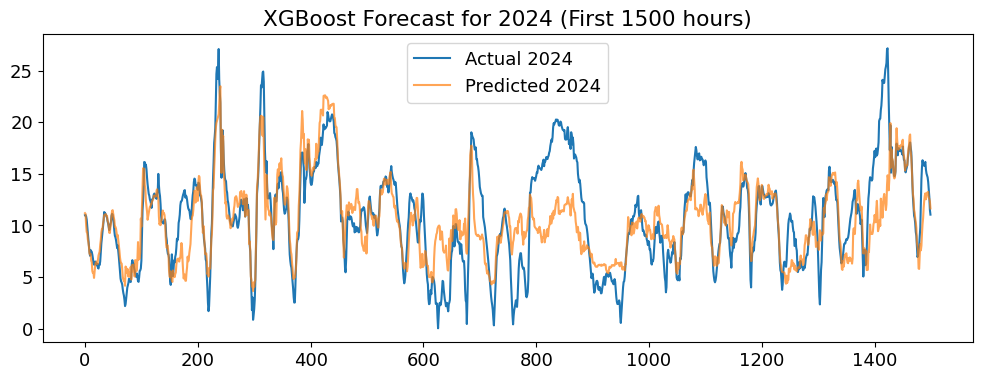

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(target_test.values[:1500], label='Actual 2024')
plt.plot(y_pred_xg[:1500], label='Predicted 2024', alpha=0.7)
plt.title('XGBoost Forecast for 2024 (First 1500 hours)')
plt.legend()
plt.show()

In [ ]:
y_pred_xg_train = xg_model.predict(features)

In [ ]:
mse = mean_squared_error(target, y_pred_xg_train)
print(f"Test MSE: {mse:.2f}")
mae = mean_absolute_error(target, y_pred_xg_train)
print("MAE:", mae)
mape = mean_absolute_percentage_error(target, y_pred_xg_train)
print(f"MAPE: {mape * 100:.2f}%")

Test MSE: 4.75
MAE: 1.6713783740997314
MAPE: 30.70%


In [ ]:
msenorm_xg_train = mean_squared_error(y_pred_xg_train/target, ones_target_train)
msenorm_xg_train

0.7463748455047607

In [ ]:
n_trees = xg_model.get_booster().num_boosted_rounds()
n_trees

200

/usr/local/lib/python3.11/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

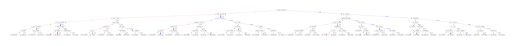

In [ ]:
from xgboost import plot_tree
plot_tree(xg_model, num_trees=199)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

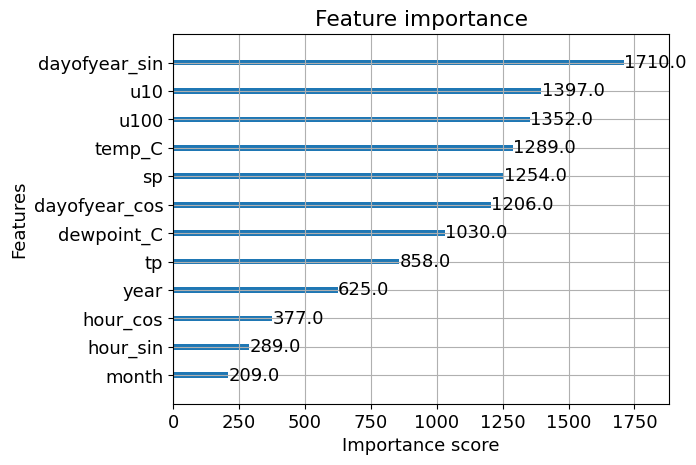

In [ ]:
from xgboost import plot_importance
plot_importance(xg_model)

##Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(features, target)

y_pred_rf = rf_model.predict(features_test)
mse_rf = mean_squared_error(target_test, y_pred_rf)
print(f"Random Forest MSE: {mse_rf:.3f}")

Random Forest MSE: 10.147


In [ ]:
mae = mean_absolute_error(target_test, y_pred_rf)
print("MAE:", mae)
mape = mean_absolute_percentage_error(target_test, y_pred_rf)
print(f"MAPE: {mape * 100:.2f}%")

MAE: 2.3763916906169955
MAPE: 42.80%


In [ ]:
msenorm_rf = mean_squared_error(y_pred_rf/target_test, ones_target_test)
msenorm_rf

11.821177461218863

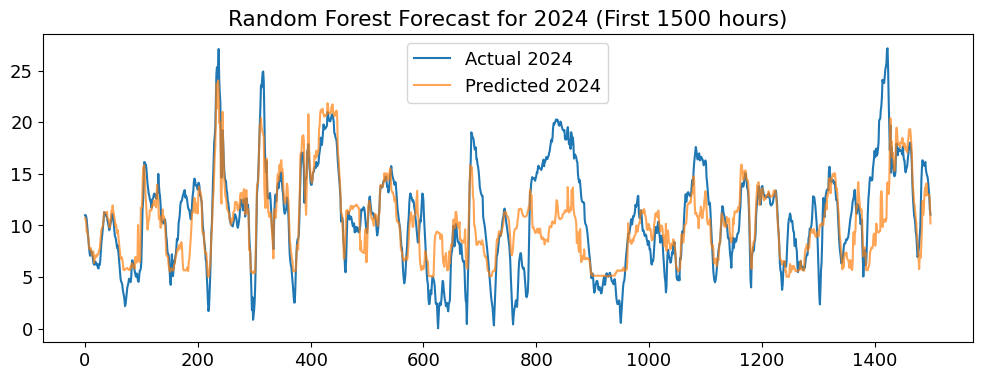

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(target_test.values[:1500], label='Actual 2024')
plt.plot(y_pred_rf[:1500], label='Predicted 2024', alpha=0.7)
plt.title('Random Forest Forecast for 2024 (First 1500 hours)')
plt.legend()
plt.show()

In [ ]:
y_pred_rf_train = rf_model.predict(features)

In [ ]:
mse = mean_squared_error(target, y_pred_rf_train)
print(f"Test MSE: {mse:.2f}")
mae = mean_absolute_error(target, y_pred_rf_train)
print("MAE:", mae)
mape = mean_absolute_percentage_error(target, y_pred_rf_train)
print(f"MAPE: {mape * 100:.2f}%")

Test MSE: 6.36
MAE: 1.9077645723130197
MAPE: 36.80%


In [ ]:
msenorm_rf_train = mean_squared_error(y_pred_rf_train/target, ones_target_train)
msenorm_rf_train

1.1028035553770201

##Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(features, target)

y_pred_lr = lr_model.predict(features_test)
mse_lr = mean_squared_error(target_test, y_pred_lr)
print(f"Linear Regression MSE: {mse_lr:.3f}")

Linear Regression MSE: 15.083


In [ ]:
mae = mean_absolute_error(target_test, y_pred_lr)
print("MAE:", mae)
mape = mean_absolute_percentage_error(target_test, y_pred_lr)
print(f"MAPE: {mape * 100:.2f}%")

MAE: 3.079612339987643
MAPE: 57.20%


In [ ]:
msenorm_lr = mean_squared_error(y_pred_lr/target_test, ones_target_test)
msenorm_lr

11.709369811183109

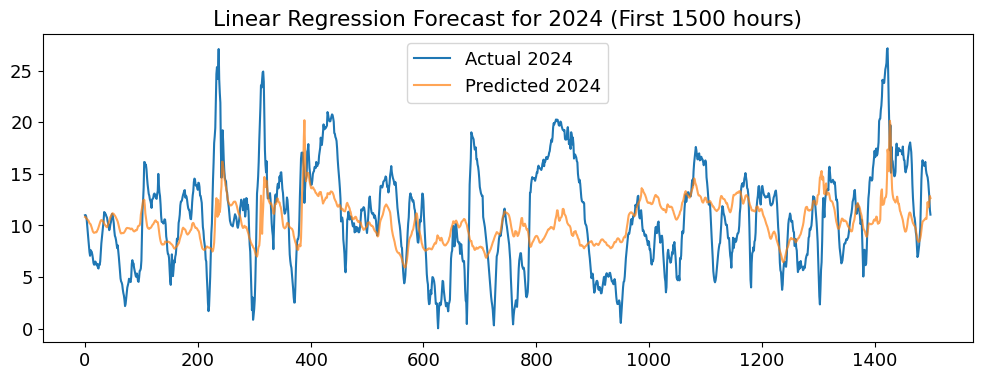

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(target_test.values[:1500], label='Actual 2024')
plt.plot(y_pred_lr[:1500], label='Predicted 2024', alpha=0.7)
plt.title('Linear Regression Forecast for 2024 (First 1500 hours)')
plt.legend()
plt.show()

In [ ]:
y_pred_lr_train = lr_model.predict(features)

In [ ]:
mse = mean_squared_error(target, y_pred_lr_train)
print(f"Test MSE: {mse:.2f}")
mae = mean_absolute_error(target, y_pred_lr_train)
print("MAE:", mae)
mape = mean_absolute_percentage_error(target, y_pred_lr_train)
print(f"MAPE: {mape * 100:.2f}%")

Test MSE: 14.99
MAE: 3.07693702678196
MAPE: 58.41%


In [ ]:
msenorm_lr_train = mean_squared_error(y_pred_lr_train/target, ones_target_train)
msenorm_lr_train

2.3896606492448806

##M5 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
tree = DecisionTreeRegressor(max_leaf_nodes=50, min_samples_leaf=100, random_state=42)
tree.fit(features, target)

DecisionTreeRegressor(max_leaf_nodes=50, min_samples_leaf=100, random_state=42)

In [ ]:
leaf_indices = tree.apply(features)

In [ ]:
print(leaf_indices[:5])

[45 45 45 46 46]


In [ ]:
leaf_models = {}
for leaf in np.unique(leaf_indices):
    idx = np.where(leaf_indices == leaf)[0]
    X_leaf = features.iloc[idx]
    y_leaf = target.iloc[idx]

    m5dt_model = LinearRegression()
    m5dt_model.fit(X_leaf, y_leaf)
    leaf_models[leaf] = m5dt_model

In [ ]:
# Get leaf for each test sample
leaf_test = tree.apply(features_test)

# Predict using the corresponding local model
y_pred_m5dt = np.array([
    leaf_models[leaf].predict(features_test.iloc[i].values.reshape(1, -1))[0]
    for i, leaf in enumerate(leaf_test)
])


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warn

In [ ]:
mse_m5dt = mean_squared_error(target_test, y_pred_m5dt)
print(f"M5 Decision Tree MSE: {mse_m5dt:.3f}")

M5 Decision Tree MSE: 10.999


In [ ]:
mae = mean_absolute_error(target_test, y_pred_m5dt)
print("MAE:", mae)
mape = mean_absolute_percentage_error(target_test, y_pred_m5dt)
print(f"MAPE: {mape * 100:.2f}%")

MAE: 2.436026907534975
MAPE: 43.87%


In [ ]:
msenorm_m5dt = mean_squared_error(y_pred_m5dt/target_test, ones_target_test)
msenorm_m5dt

11.94015551567553

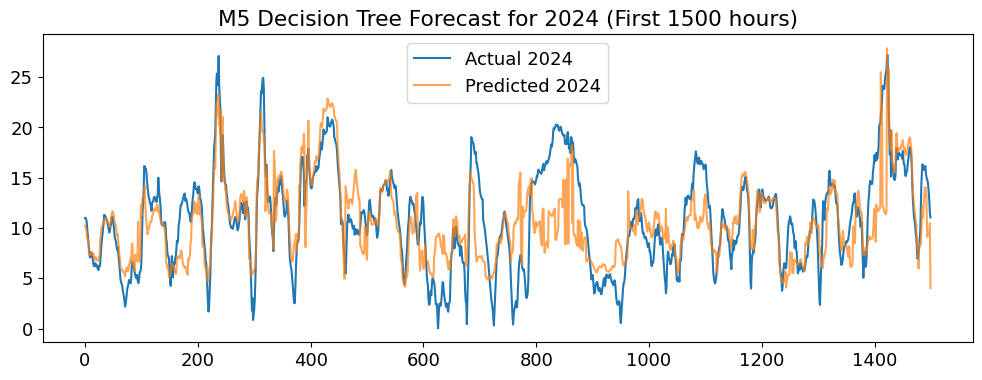

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(target_test.values[:1500], label='Actual 2024')
plt.plot(y_pred_m5dt[:1500], label='Predicted 2024', alpha=0.7)
plt.title('M5 Decision Tree Forecast for 2024 (First 1500 hours)')
plt.legend()
plt.show()

In [ ]:
leaf_indices_train = tree.apply(features)

In [ ]:
# Predict on training set
y_pred_m5dt_train = np.array([
    leaf_models[leaf].predict(features.iloc[i].values.reshape(1, -1))[0]
    for i, leaf in enumerate(leaf_indices_train)
])

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warn

In [ ]:
mse = mean_squared_error(target, y_pred_m5dt_train)
print(f"Test MSE: {mse:.2f}")
mae = mean_absolute_error(target, y_pred_m5dt_train)
print("MAE:", mae)
mape = mean_absolute_percentage_error(target, y_pred_m5dt_train)
print(f"MAPE: {mape * 100:.2f}%")

Test MSE: 7.09
MAE: 2.0289802563191275
MAPE: 36.08%


In [ ]:
msenorm_m5dt_train = mean_squared_error(y_pred_m5dt_train/target, ones_target_train)
msenorm_m5dt_train

0.9908031222879017

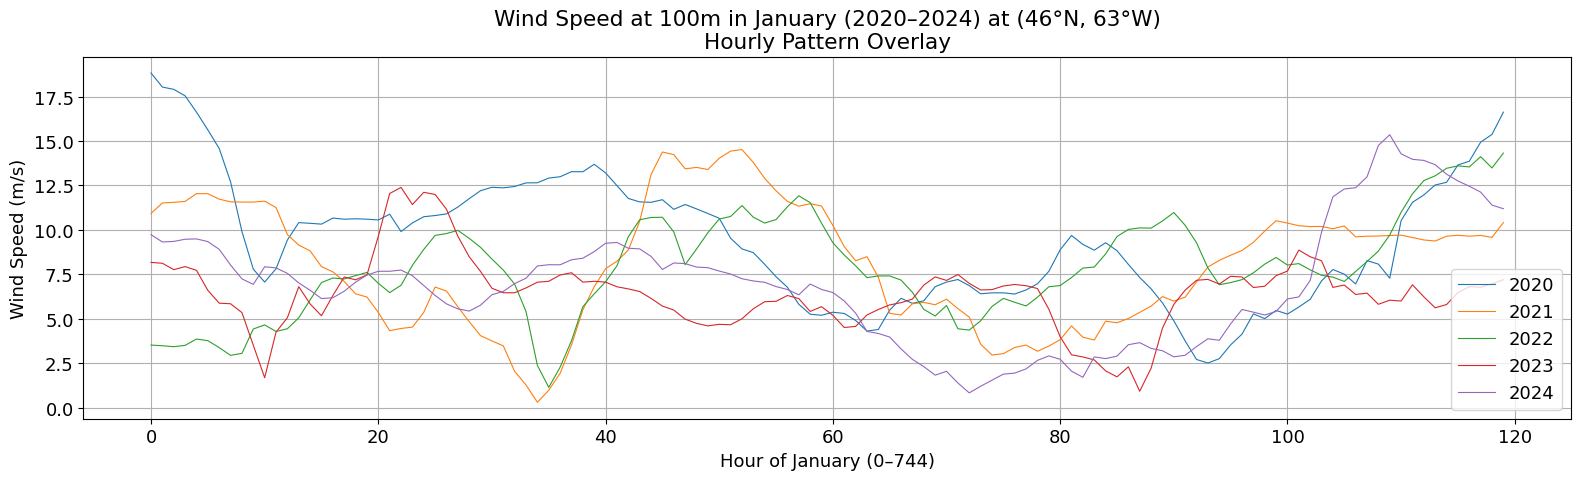

In [ ]:
plt.figure(figsize=(16, 5))

# Loop through each year
for year in range(2020, 2025):
    ds = globals()[f'wnd100{year}']
    point_data = ds['wind_speed_100m'].sel(latitude=46.0, longitude=-63.0)

    # Select January of that year
    subset = point_data.sel(valid_time=slice(f'{year}-01-01', f'{year}-01-05'))

    # Reset the time axis to be just hour number (0–744)
    hours = range(len(subset))

    # Plot with label
    plt.plot(hours, subset.values, label=str(year), linewidth=0.8)

# Customize plot
plt.title('Wind Speed at 100m in January (2020–2024) at (46°N, 63°W)\nHourly Pattern Overlay')
plt.xlabel('Hour of January (0–744)')
plt.ylabel('Wind Speed (m/s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


##WCT

##LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [ ]:
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X.iloc[i:i+window_size].values)
        ys.append(y.iloc[i+window_size])
    return np.array(Xs), np.array(ys)

window_size = 24  # past 24 hours
X_train_seq, y_train_seq = create_sequences(features, target, window_size)


In [ ]:
n_features = X_train_seq.shape[2]

lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='tanh', input_shape=(window_size, n_features)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

early_stop = EarlyStopping(patience=2, min_delta=0.1, restore_best_weights=True)

lstm_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=64, verbose=1, callbacks=[early_stop])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 35.0847
Epoch 2/50
 34/548 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 10.7389

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 11.0523
Epoch 3/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 9.9317
Epoch 4/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 9.3090
Epoch 5/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 8.5237
Epoch 6/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 7.6429
Epoch 7/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.1320
Epoch 8/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.5070
Epoch 9/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5.9728
Epoch 10/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 5.5032
Epoch 11/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.0719
Epoch 12/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.6624
Epoch 13/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.4084
Epoch 14/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.0180
Epoch 15/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.8021
Epoch 16/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.575

In [ ]:
X_2024_all = features_test.copy()
predictions_2024 = []

# Start with the first 24 hours of 2024
rolling_window = X_2024_all.iloc[:window_size].values

for i in range(window_size, len(X_2024_all)):
    X_input = rolling_window[-window_size:].reshape(1, window_size, n_features)
    y_pred_lstm = lstm_model.predict(X_input)[0, 0]
    predictions_2024.append(y_pred_lstm)

    # Create next input row by copying the actual features for that hour
    next_input_row = X_2024_all.iloc[i].values.copy()

    # Replace the wind_speed_10m feature with the predicted value if it's part of input
    # (only if wind speed was used as a lagged feature)
    # next_input_row[input_feature_index] = y_pred

    # Update rolling window
    rolling_window = np.vstack([rolling_window[1:], next_input_row])


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

LSTM Recursive MSE (2024): 17.434


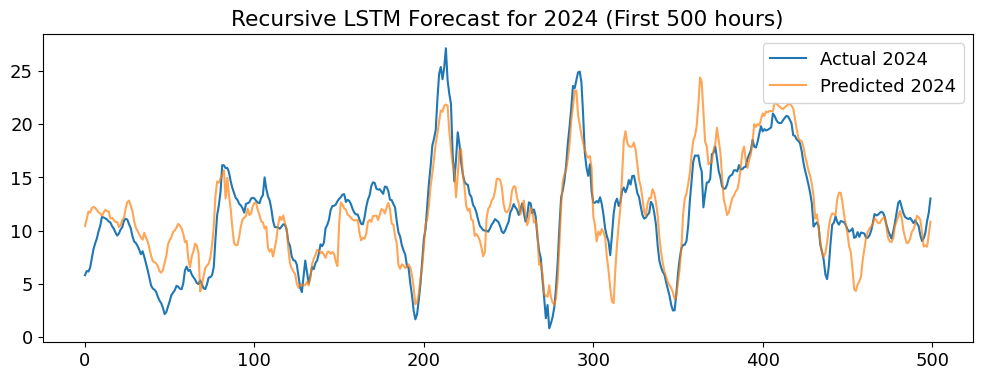

In [ ]:
# Align y_test and predictions
y_true = target_test.iloc[window_size:len(predictions_2024)+window_size]
mse = mean_squared_error(y_true, predictions_2024)
print(f"LSTM Recursive MSE (2024): {mse:.3f}")

plt.figure(figsize=(12, 4))
plt.plot(y_true.values[:500], label='Actual 2024')
plt.plot(predictions_2024[:500], label='Predicted 2024', alpha=0.7)
plt.title('Recursive LSTM Forecast for 2024 (First 500 hours)')
plt.legend()
plt.show()

In [ ]:
mae = mean_absolute_error(y_true, predictions_2024)
print("MAE:", mae)
mape = mean_absolute_percentage_error(y_true, predictions_2024)
print(f"MAPE: {mape * 100:.2f}%")

MAE: 3.118344306945801
MAPE: 48.49%


In [ ]:
ones_y_true = np.ones_like(y_true)

In [ ]:
msenorm_m5dt = mean_squared_error(predictions_2024/y_true, ones_y_true)
msenorm_m5dt

2.9316704273223877

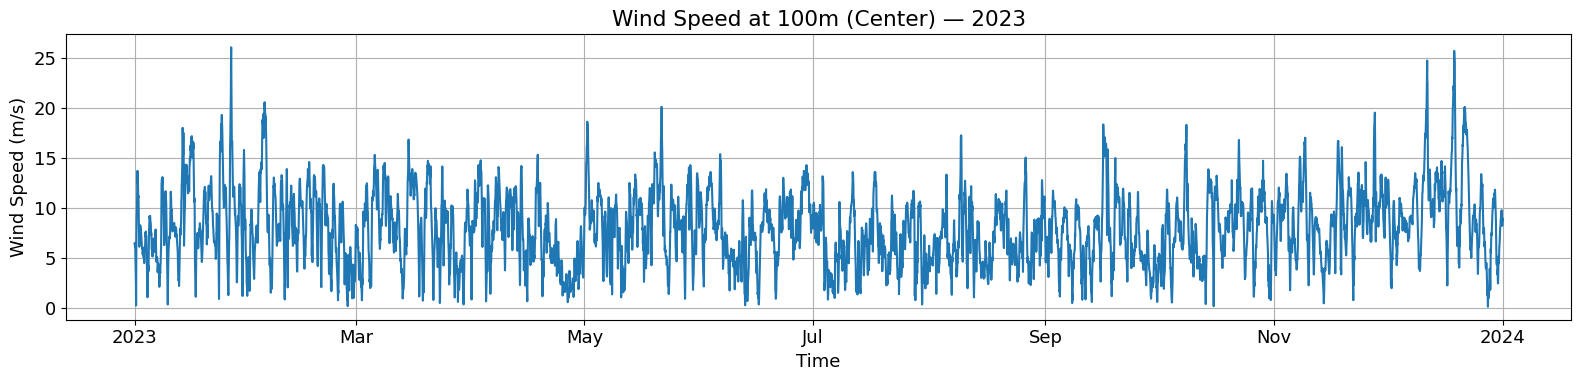

In [ ]:
# Method 2: Using actual lat/lon values with method='nearest'
wind_ts = combined2023['wind_speed_100m'].sel(latitude=46.5, longitude=-63.75)
# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts.plot()
plt.title("Wind Speed at 100m (Center) — 2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

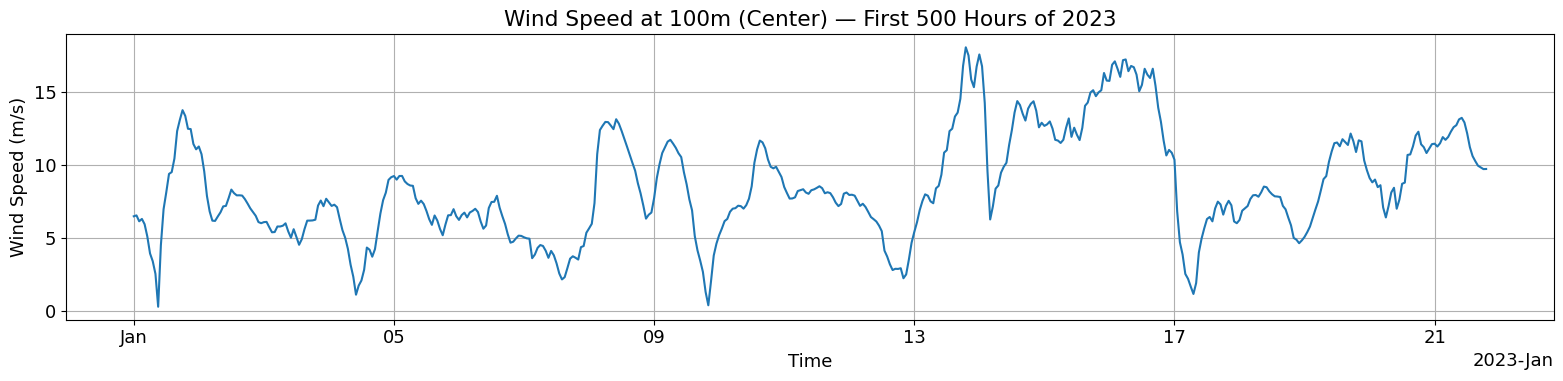

In [ ]:
# Select wind speed time series at specified lat/lon using nearest grid point
wind_ts = combined2023['wind_speed_100m'].sel(latitude=46.5, longitude=-63.75, method='nearest')

# Slice to first 500 hours
wind_ts_500 = wind_ts.isel(valid_time=slice(0, 500))

# Plot
plt.figure(figsize=(16, 4))  # Wider plot for better time resolution
wind_ts_500.plot()
plt.title("Wind Speed at 100m (Center) — First 500 Hours of 2023")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
X_202023_all = features.copy()
predictions_202023 = []

# Start with the first 24 hours of 2020
rolling_window = X_202023_all.iloc[:window_size].values

for i in range(window_size, len(X_202023_all)):
    X_input = rolling_window[-window_size:].reshape(1, window_size, n_features)
    y_pred = lstm_model.predict(X_input)[0, 0]
    predictions_202023.append(y_pred)

    # Create next input row by copying the actual features for that hour
    next_input_row = X_202023_all.iloc[i].values.copy()

    # Replace the wind_speed_10m feature with the predicted value if it's part of input
    # (only if wind speed was used as a lagged feature)
    # next_input_row[input_feature_index] = y_pred

    # Update rolling window
    rolling_window = np.vstack([rolling_window[1:], next_input_row])

Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

In [ ]:
y_true = target.iloc[window_size:len(predictions_202023)+window_size]
mse = mean_squared_error(y_true, predictions_202023)
print(f"LSTM Recursive MSE (2020-2023): {mse:.3f}")

LSTM Recursive MSE (2020-2023): 1.010


In [ ]:
pd.Series(predictions_2024).to_csv("/content/drive/MyDrive/Colab Notebooks/lstm_test.csv", index=True, header=True)

In [ ]:

mae = mean_absolute_error(y_true, predictions_202023)
print("MAE:", mae)
mape = mean_absolute_percentage_error(y_true, predictions_202023)
print(f"MAPE: {mape * 100:.2f}%")

MAE: 0.7673715353012085
MAPE: 12.20%


In [ ]:
ones_lstm = np.ones_like(y_true)

In [ ]:
msenorm_lstm = mean_squared_error(predictions_202023/y_true, ones_lstm)
msenorm_lstm

0.11830855160951614

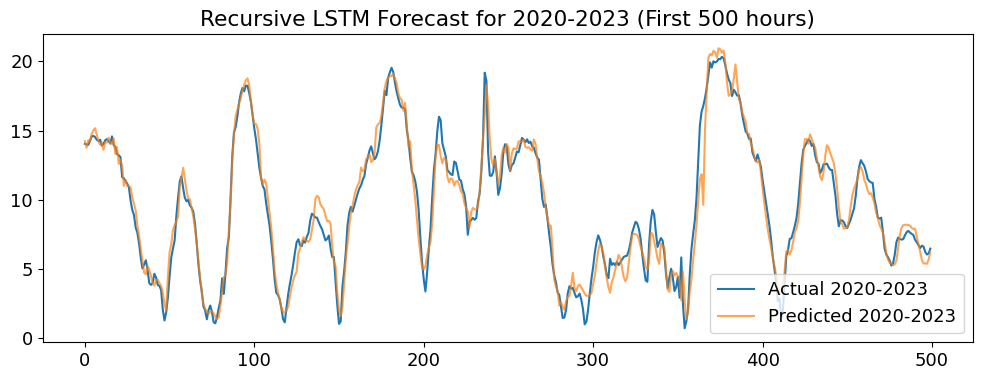

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(y_true.values[:500], label='Actual 2020-2023')
plt.plot(predictions_202023[:500], label='Predicted 2020-2023', alpha=0.7)
plt.title('Recursive LSTM Forecast for 2020-2023 (First 500 hours)')
plt.legend()
plt.show()

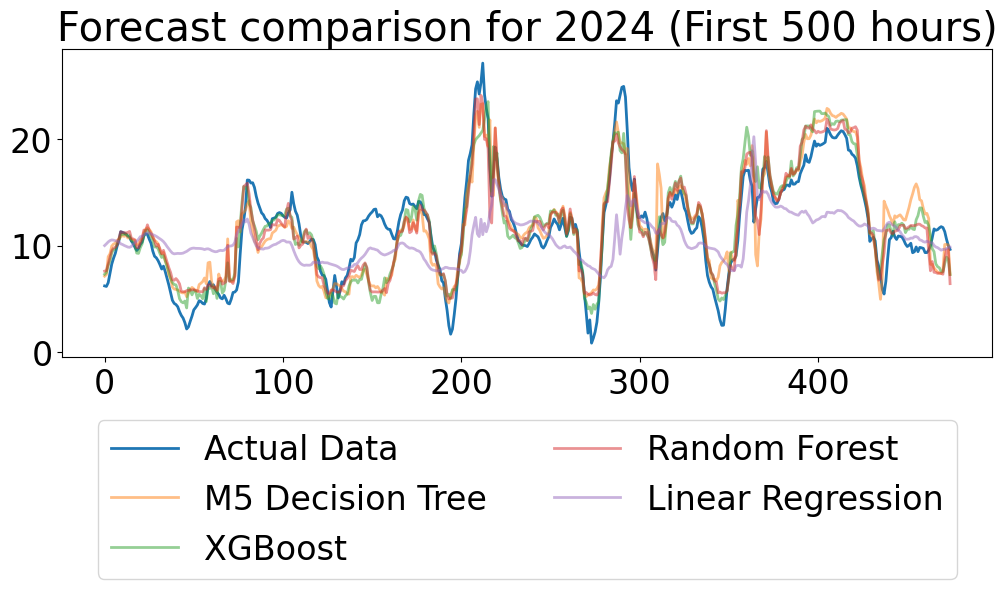

In [ ]:
#y_true = target_test.iloc[window_size:len(predictions_2024)+window_size]
#test_lstm = predictions_2024.iloc[window_size:len(target_test)+window_size]

plt.rcParams['font.size'] = 24

plt.figure(figsize=(12, 4))
#plt.plot(y_true.values[:500], label='Actual 2024')
plt.plot(target_test.values[25:500], label='Actual Data', linewidth=2)
plt.plot(y_pred_m5dt[25:500], label='M5 Decision Tree', alpha=0.5, linewidth=2)
plt.plot(y_pred_xg[25:500], label='XGBoost', alpha=0.5, linewidth=2)
plt.plot(y_pred_rf[25:500], label='Random Forest', alpha=0.5, linewidth=2)
plt.plot(y_pred_lr[25:500], label='Linear Regression', alpha=0.5, linewidth=2)
# plt.plot(predictions_2024[:475], label='LSTM', alpha=0.5, linewidth=2)
plt.title('Forecast comparison for 2024 (First 500 hours)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.show()

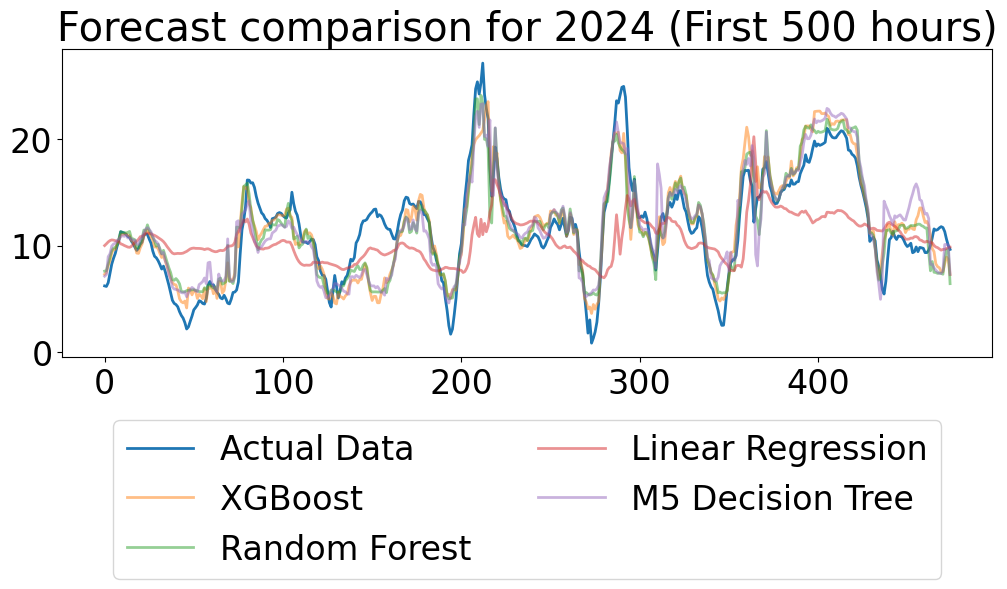

In [ ]:
#y_true = target_test.iloc[window_size:len(predictions_2024)+window_size]
#test_lstm = predictions_2024.iloc[window_size:len(target_test)+window_size]

plt.rcParams['font.size'] = 24

plt.figure(figsize=(12, 4))
#plt.plot(y_true.values[:500], label='Actual 2024')
plt.plot(target_test.values[25:500], label='Actual Data', linewidth=2)
#plt.plot(y_pred_xg[25:500], label='XGBoost', alpha=0.5, linewidth=2)
#plt.plot(y_pred_rf[25:500], label='Random Forest', alpha=0.5, linewidth=2)
#plt.plot(y_pred_lr[25:500], label='Linear Regression', alpha=0.5, linewidth=2)
plt.plot(y_pred_m5dt[25:500], label='M5 Decision Tree', alpha=0.5, linewidth=2)
# plt.plot(predictions_2024[:475], label='LSTM', alpha=0.5, linewidth=2)
plt.title('Forecast comparison for 2024 (First 500 hours)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.show()